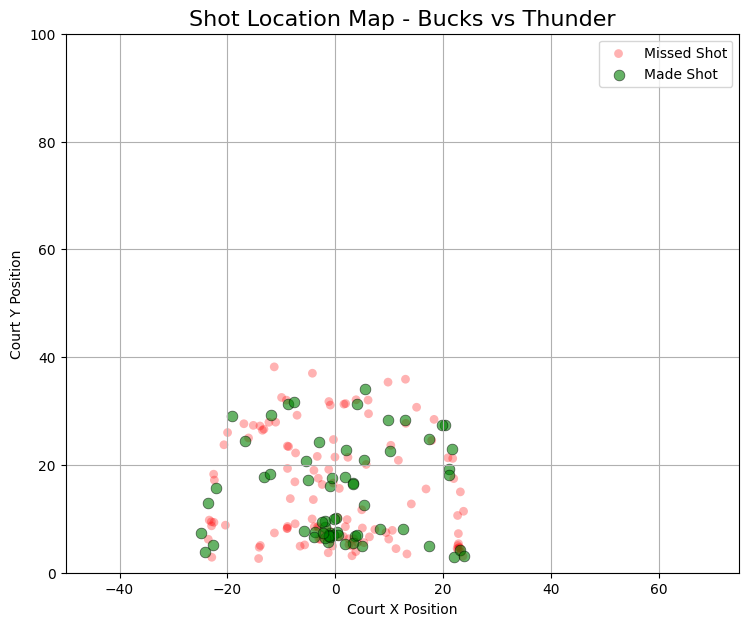

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Made and missed shots
made_shots = df[df['fg'] == 1]
missed_shots = df[df['fg'] == 0]

# Plot
plt.figure(figsize=(12, 7))

# Plot missed shots first (so made shots layer on top)
plt.scatter(missed_shots['loc_x'], missed_shots['loc_y'],
            c='red', label='Missed Shot', alpha=0.3, s=40, edgecolors='none')

# Then plot made shots
plt.scatter(made_shots['loc_x'], made_shots['loc_y'],
            c='green', label='Made Shot', alpha=0.6, s=60, edgecolors='black', linewidths=0.5)

# Court formatting
plt.title('Shot Location Map - Bucks vs Thunder', fontsize=16)
plt.xlabel('Court X Position')
plt.ylabel('Court Y Position')

# Zoom into real area (based on your actual data spread)
plt.xlim(-50, 75)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()



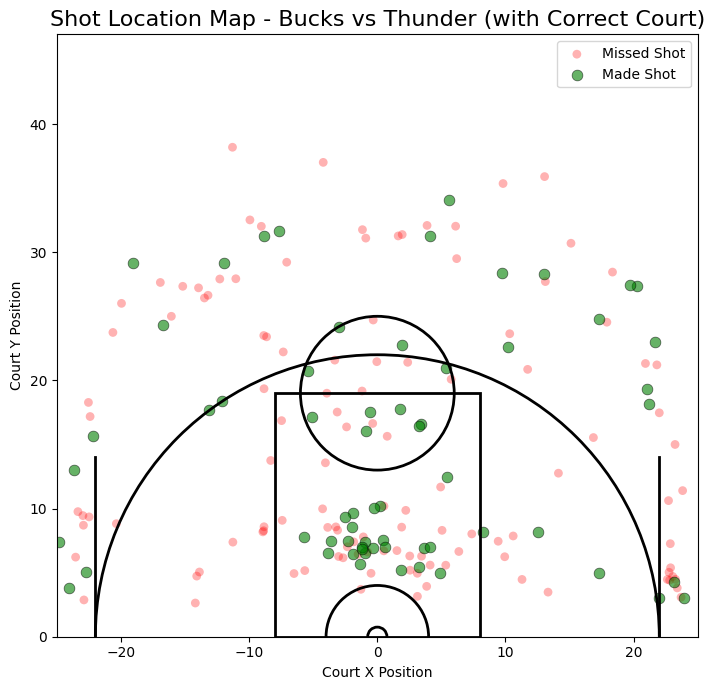

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.patches as patches

# Load your shot data
df = pd.read_csv("data_mil_okc_121724_shots.csv")

# Filter shots by made or missed
made_shots = df[df['fg'] == 1]
missed_shots = df[df['fg'] == 0]

# Draw a half-court with NBA dimensions
def draw_half_court(ax=None):
    if ax is None:
        ax = plt.gca()

    hoop = plt.Circle((0, 0), radius=0.75, linewidth=2, color='black', fill=False)
    backboard = plt.Rectangle((-3, -0.75), 6, -0.1, linewidth=2, color='black')
    paint = plt.Rectangle((-8, 0), 16, 19, linewidth=2, color='black', fill=False)
    free_throw_circle = plt.Circle((0, 19), 6, linewidth=2, color='black', fill=False)
    restricted = plt.Circle((0, 0), 4, linewidth=2, color='black', fill=False)
    corner3_left = plt.Line2D([-22, -22], [0, 14], linewidth=2, color='black')
    corner3_right = plt.Line2D([22, 22], [0, 14], linewidth=2, color='black')
    arc = Arc((0, 0), 44.0, 44.0, theta1=0, theta2=180, linewidth=2, color='black')

    elements = [hoop, backboard, paint, free_throw_circle, restricted, 
                corner3_left, corner3_right, arc]

    for element in elements:
        if isinstance(element, plt.Line2D):
            ax.add_line(element)
        else:
            ax.add_patch(element)

    return ax

# Plotting
plt.figure(figsize=(12, 7))
ax = plt.gca()

plt.scatter(missed_shots['loc_x'], missed_shots['loc_y'], 
            c='red', label='Missed Shot', alpha=0.3, s=40, edgecolors='none')
plt.scatter(made_shots['loc_x'], made_shots['loc_y'], 
            c='green', label='Made Shot', alpha=0.6, s=60, edgecolors='black', linewidths=0.5)

draw_half_court(ax)
plt.title('Shot Location Map - Bucks vs Thunder (with Correct Court)', fontsize=16)
plt.xlabel('Court X Position')
plt.ylabel('Court Y Position')
plt.xlim(-25, 25)
plt.ylim(0, 47)
plt.legend()
plt.grid(False)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


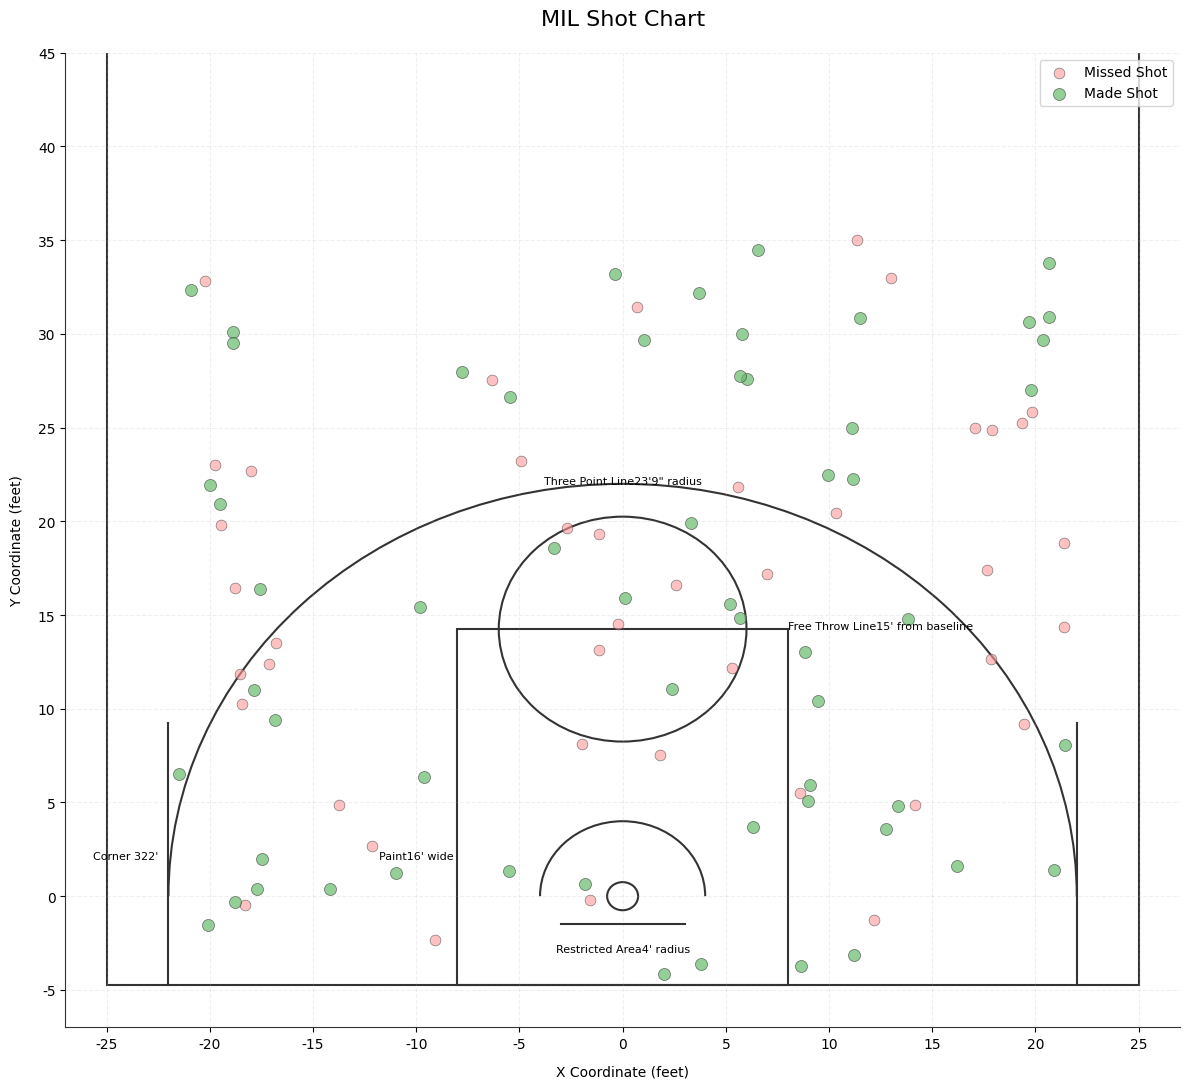

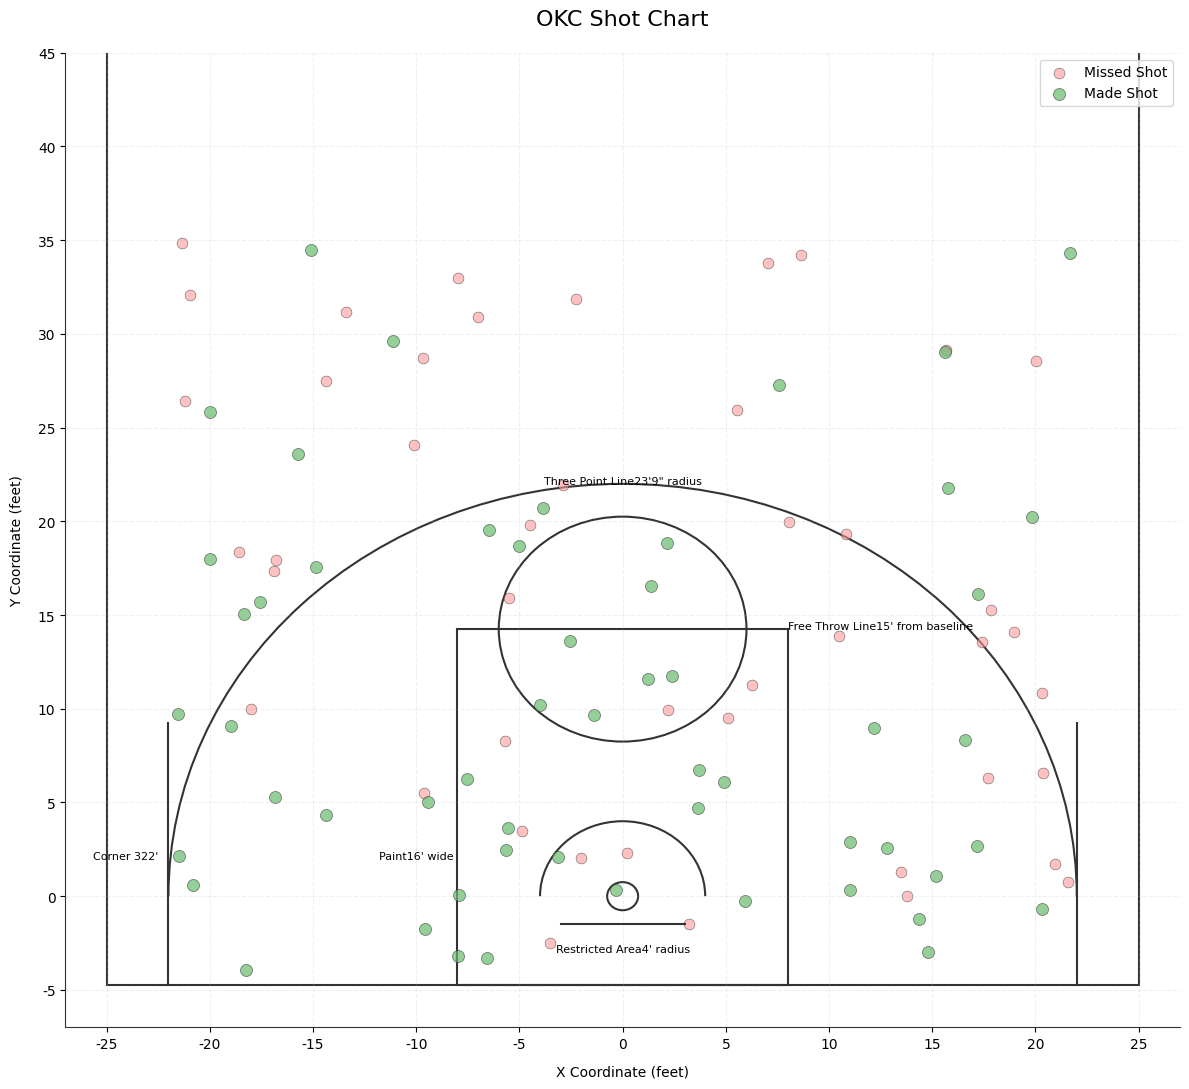

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, Rectangle
import numpy as np

def draw_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()
    
    # Court elements with measurements in feet
    court_elements = [
        Rectangle((-25, -4.75), 50, 51.75, linewidth=lw, color=color, fill=False),
        Rectangle((-8, -4.75), 16, 19, linewidth=lw, color=color, fill=False),
        Circle((0, 0), 0.75, linewidth=lw, color=color, fill=False),
        Arc((0, 0), 8, 8, theta1=0, theta2=180, linewidth=lw, color=color),
        Circle((0, 14.25), 6, linewidth=lw, color=color, fill=False),
        Arc((0, 0), 44, 44, theta1=0, theta2=180, linewidth=lw, color=color)
    ]
    
    for element in court_elements:
        ax.add_patch(element)

    # Three-point lines
    ax.plot([-22, -22], [-4.75, 9.25], color=color, linewidth=lw)
    ax.plot([22, 22], [-4.75, 9.25], color=color, linewidth=lw)
    
    # Backboard
    ax.plot([-3, 3], [-1.5, -1.5], color=color, linewidth=lw)
    
    # Add measurement labels
    plt.text(0, -3, "Restricted Area\
4' radius", ha='center', fontsize=8)
    plt.text(-10, 2, "Paint\
16' wide", ha='center', fontsize=8)
    plt.text(-24, 2, "Corner 3\
22' ", ha='center', fontsize=8)
    plt.text(0, 22, "Three Point Line\
23'9\" radius", ha='center', fontsize=8)
    plt.text(8, 14.25, "Free Throw Line\
15' from baseline", ha='left', fontsize=8)
    
    return ax

def plot_shot_map(shots_df, team_name):
    plt.figure(figsize=(12, 11))
    ax = plt.gca()
    
    # Set background and style
    ax.set_facecolor('white')
    plt.gcf().set_facecolor('white')
    
    # Draw court
    draw_court(ax, color='#333333')
    
    # Plot shots
    made_shots = shots_df[shots_df['fg'] == 1]
    missed_shots = shots_df[shots_df['fg'] == 0]
    
    plt.scatter(missed_shots['loc_x'], missed_shots['loc_y'], 
               color='#FF9999', label='Missed Shot',
               alpha=0.6, s=60, edgecolors='#333333', linewidths=0.5)
    
    plt.scatter(made_shots['loc_x'], made_shots['loc_y'], 
               color='#66BB6A', label='Made Shot',
               alpha=0.7, s=75, edgecolors='#333333', linewidths=0.5)
    
    # Styling
    plt.title(f'{team_name} Shot Chart', fontsize=16, pad=20)
    plt.legend(loc='upper right', frameon=True)
    
    # Set limits
    plt.xlim(-27, 27)
    plt.ylim(-7, 45)
    
    # Add and style axes
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # X-axis ticks and label
    x_ticks = np.arange(-25, 26, 5)
    plt.xticks(x_ticks, [str(x) for x in x_ticks])
    plt.xlabel('X Coordinate (feet)', fontsize=10, labelpad=10)
    
    # Y-axis ticks and label
    y_ticks = np.arange(-5, 46, 5)
    plt.yticks(y_ticks, [str(y) for y in y_ticks])
    plt.ylabel('Y Coordinate (feet)', fontsize=10, labelpad=10)
    
    # Grid (optional, light)
    plt.grid(True, linestyle='--', alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# Create sample data
np.random.seed(42)
num_samples = 200
teams = np.random.choice(['MIL', 'OKC'], size=num_samples)
fg = np.random.choice([0, 1], size=num_samples, p=[0.45, 0.55])
loc_x = np.random.uniform(-22, 22, num_samples)
loc_y = np.random.uniform(-4.75, 35, num_samples)

df = pd.DataFrame({
    'team_nba_off': teams,
    'fg': fg,
    'loc_x': loc_x,
    'loc_y': loc_y
})

# Generate shot maps
teams_to_plot = ['MIL', 'OKC']
for team in teams_to_plot:
    team_shots = df[df['team_nba_off'] == team]
    plot_shot_map(team_shots, team)

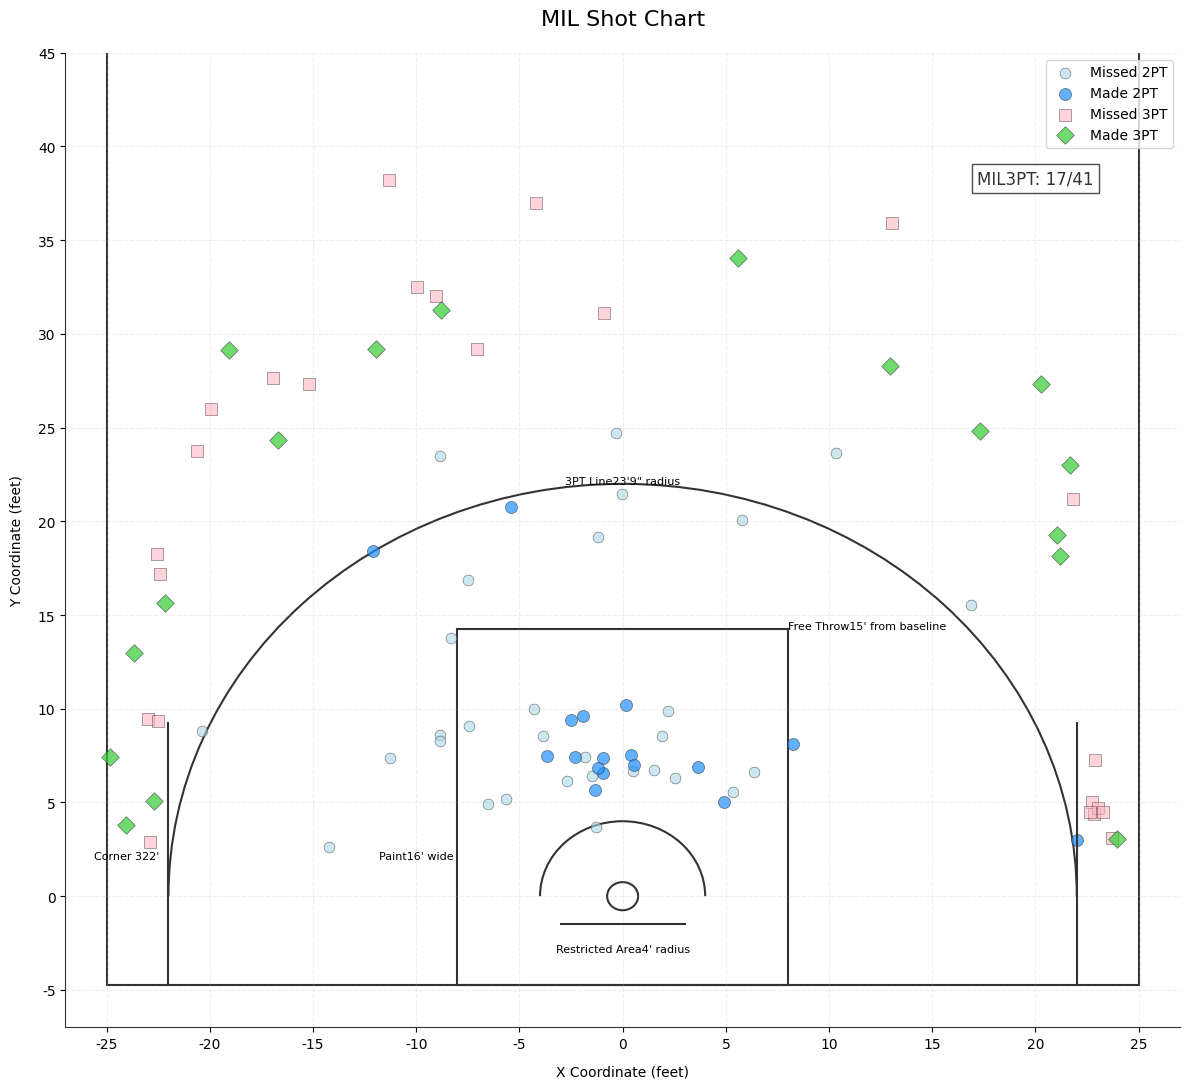

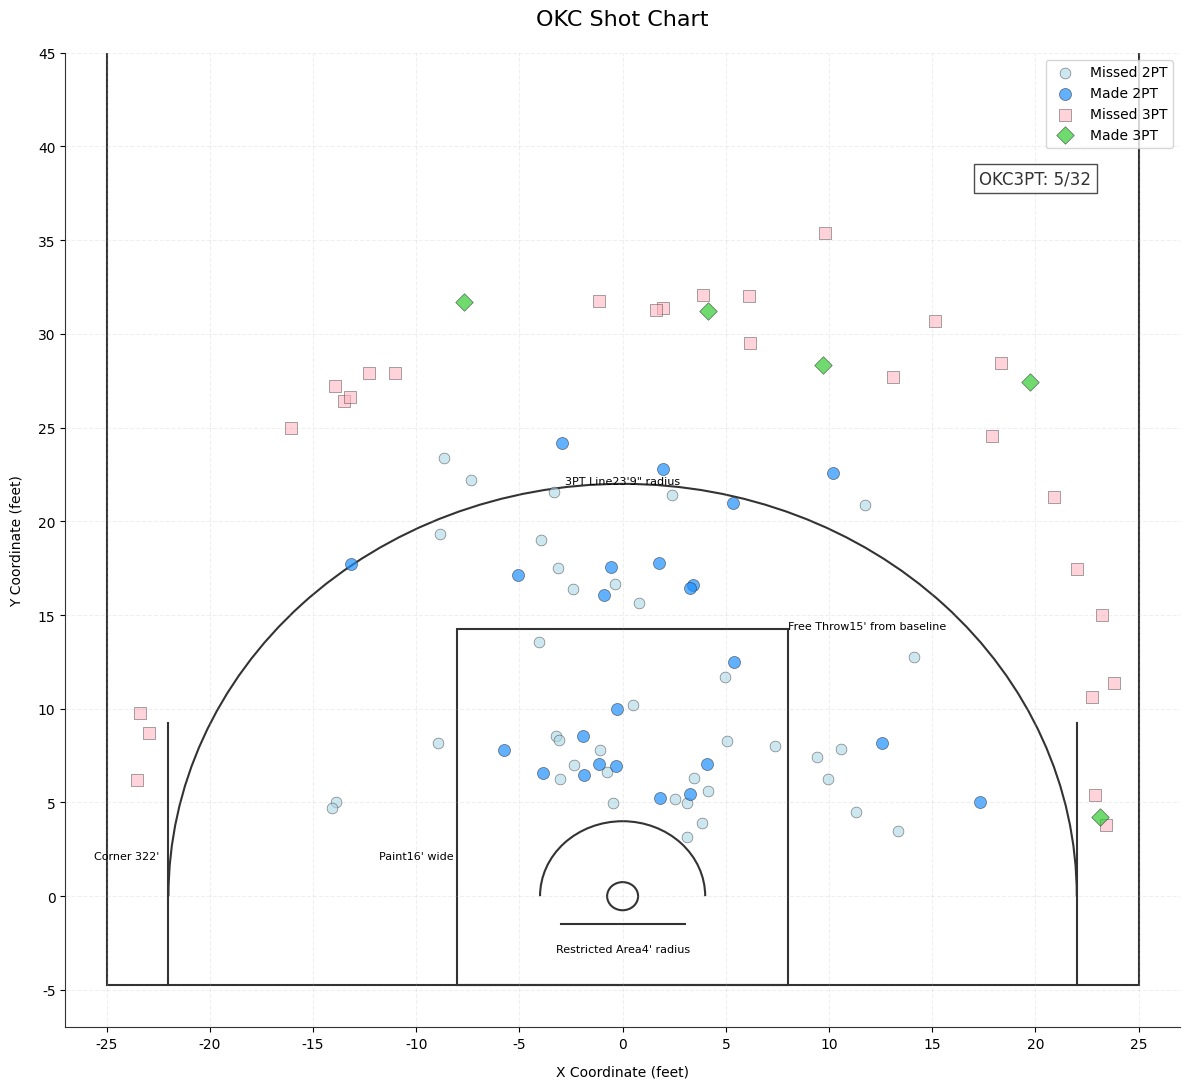

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, Rectangle
import numpy as np

# Define the improved shot chart function with three-point split

def draw_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()
    
    # Court outline
    court = Rectangle((-25, -4.75), 50, 51.75, linewidth=lw, color=color, fill=False)
    ax.add_patch(court)
    
    # Paint
    paint = Rectangle((-8, -4.75), 16, 19, linewidth=lw, color=color, fill=False)
    ax.add_patch(paint)
    
    # Restricted area arc
    restricted = Arc((0, 0), 8, 8, theta1=0, theta2=180, linewidth=lw, color=color)
    ax.add_patch(restricted)
    
    # Hoop
    hoop = Circle((0, 0), 0.75, linewidth=lw, color=color, fill=False)
    ax.add_patch(hoop)
    
    # Backboard
    ax.plot([-3, 3], [-1.5, -1.5], color=color, linewidth=lw)
    
    # Three point line - corners
    ax.plot([-22, -22], [-4.75, 9.25], color=color, linewidth=lw)
    ax.plot([22, 22], [-4.75, 9.25], color=color, linewidth=lw)
    
    # Three point arc
    three_arc = Arc((0, 0), 44, 44, theta1=0, theta2=180, linewidth=lw, color=color)
    ax.add_patch(three_arc)
    
    # Add dimension labels (optional)
    plt.text(0, -3, "Restricted Area\
4' radius", ha='center', fontsize=8)
    plt.text(-10, 2, "Paint\
16' wide", ha='center', fontsize=8)
    plt.text(-24, 2, "Corner 3\
22'", ha='center', fontsize=8)
    plt.text(0, 22, "3PT Line\
23'9\" radius", ha='center', fontsize=8)
    plt.text(8, 14.25, "Free Throw\
15' from baseline", ha='left', fontsize=8)
    
    return ax


def plot_shot_map(shots_df, team_name):
    plt.figure(figsize=(12, 11))
    ax = plt.gca()
    
    # Set background
    ax.set_facecolor('white')
    plt.gcf().set_facecolor('white')
    
    # Draw the court
    draw_court(ax, color='#333333')
    
    # Filter shots into three pointers and others
    three_df = shots_df[shots_df['three'] == 1]
    non_three_df = shots_df[shots_df['three'] != 1]
    
    # Plot non-three pointers (2-point shots)
    # Made shots in non-three:
    made_non_three = non_three_df[non_three_df['fg'] == 1]
    missed_non_three = non_three_df[non_three_df['fg'] == 0]
    
    plt.scatter(missed_non_three['loc_x'], missed_non_three['loc_y'], 
                color='#ADD8E6', label='Missed 2PT',
                alpha=0.6, s=60, edgecolors='#333333', linewidths=0.5)
    plt.scatter(made_non_three['loc_x'], made_non_three['loc_y'], 
                color='#1E90FF', label='Made 2PT',
                alpha=0.7, s=75, edgecolors='#333333', linewidths=0.5)
    
    # Now plot three pointers
    # Made three pointers:
    made_three = three_df[three_df['fg'] == 1]
    # Missed three pointers:
    missed_three = three_df[three_df['fg'] == 0]
    
    plt.scatter(missed_three['loc_x'], missed_three['loc_y'], 
                color='#FFB6C1', label='Missed 3PT',
                marker='s', alpha=0.6, s=70, edgecolors='#333333', linewidths=0.5)
    plt.scatter(made_three['loc_x'], made_three['loc_y'], 
                color='#32CD32', label='Made 3PT',
                marker='D', alpha=0.7, s=80, edgecolors='#333333', linewidths=0.5)
    
    # Box Score label for three pointers
    made_3 = int(made_three['fg'].sum())      # made three pointers
    att_3 = three_df.shape[0]          # attempted three pointers
    plt.text(20, 38, team_name + "\
3PT: " + str(made_3) + "/" + str(att_3),
             fontsize=12, color='#333333', bbox=dict(facecolor='white', alpha=0.7), ha='center')
    
    # X and Y ticks and labels
    x_ticks = np.arange(-25, 26, 5)
    plt.xticks(x_ticks, [str(x) for x in x_ticks])
    plt.xlabel('X Coordinate (feet)', fontsize=10, labelpad=10)
    
    y_ticks = np.arange(-5, 46, 5)
    plt.yticks(y_ticks, [str(y) for y in y_ticks])
    plt.ylabel('Y Coordinate (feet)', fontsize=10, labelpad=10)
    
    plt.title(f'{team_name} Shot Chart', fontsize=16, pad=20)
    plt.legend(loc='upper right', frameon=True)
    
    # Set limits
    plt.xlim(-27, 27)
    plt.ylim(-7, 45)
    
    # Style axes
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.show()

# Load the actual game data
shot_data = pd.read_csv('data_mil_okc_121724_shots.csv')

# Generate shot charts for each team present in the data
teams = shot_data['team_nba_off'].unique()
for team in teams:
    team_shots = shot_data[shot_data['team_nba_off'] == team]
    plot_shot_map(team_shots, team)

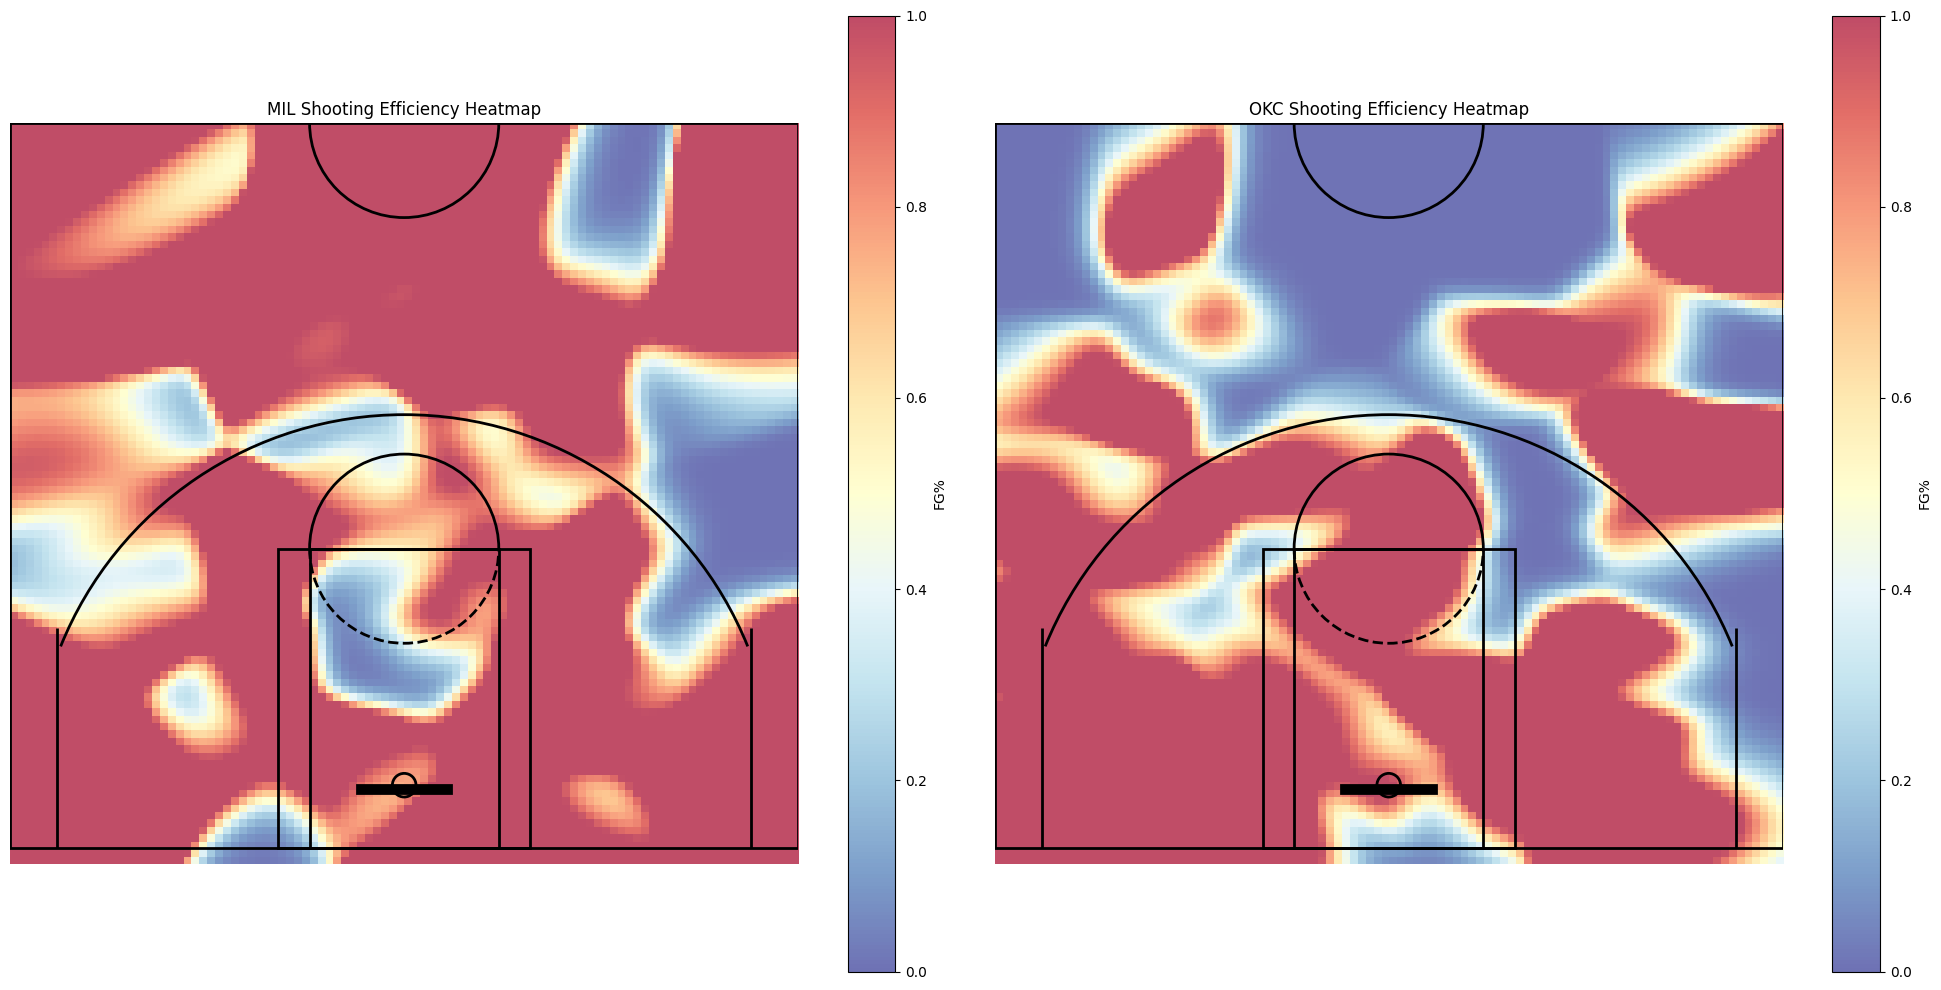

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, Arc
from scipy.stats import gaussian_kde

def draw_court(ax=None, color='black', lw=2, outer_lines=True):
    if ax is None:
        ax = plt.gca()
    
    # Basketball hoop
    hoop = Circle((0, 0), radius=0.75, linewidth=lw, color=color, fill=False)
    
    # Backboard
    backboard = Rectangle((-3, -0.5), 6, 0.5, linewidth=lw, color=color)
    
    # Paint area
    outer_box = Rectangle((-8, -4), 16, 19, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-6, -4), 12, 19, linewidth=lw, color=color, fill=False)
    
    # Free throw circle
    top_free_throw = Arc((0, 15), 12, 12, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 15), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    
    # Three point line
    corner_three_a = Rectangle((-22, -4), 0, 14, linewidth=lw, color=color)
    corner_three_b = Rectangle((22, -4), 0, 14, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 47, 47, theta1=22, theta2=158, linewidth=lw, color=color)
    
    # Center court
    center_outer_arc = Arc((0, 42), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color)
    
    # List of the court elements to be plotted
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                     bottom_free_throw, corner_three_a, corner_three_b, three_arc,
                     center_outer_arc]

    if outer_lines:
        outer_lines = Rectangle((-25, -4), 50, 46, linewidth=lw, color=color, fill=False)
        court_elements.append(outer_lines)

    for element in court_elements:
        ax.add_patch(element)
    
    return ax

plt.figure(figsize=(20, 10))
teams = ['MIL', 'OKC']

for idx, team in enumerate(teams, 1):
    team_shots = df[df['team_nba_off'] == team]
    
    plt.subplot(1, 2, idx)
    ax = plt.gca()
    
    # Create a fine mesh grid for smooth heatmap
    x_grid = np.linspace(-25, 25, 100)
    y_grid = np.linspace(-5, 42, 100)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # Initialize grid for efficiency values
    grid_efficiency = np.zeros_like(xx)
    grid_weights = np.zeros_like(xx)
    
    # Calculate weighted KDE
    positions = np.vstack([xx.ravel(), yy.ravel()])
    shot_locations = np.vstack([team_shots['loc_x'], team_shots['loc_y']])
    
    # Compute KDE with shots made as weights
    kde_made = gaussian_kde(shot_locations[:, team_shots['fg'] == 1], 
                          bw_method=0.15)  # Adjust bandwidth as needed
    z_made = kde_made(positions)
    
    # Compute KDE for all shots
    kde_all = gaussian_kde(shot_locations, bw_method=0.15)
    z_all = kde_all(positions)
    
    # Calculate efficiency where there are shots
    z_efficiency = np.zeros_like(z_all)
    mask = z_all > 0
    z_efficiency[mask] = z_made[mask] / z_all[mask]
    
    # Reshape back to grid
    efficiency = z_efficiency.reshape(xx.shape)
    
    # Draw court
    draw_court(ax, outer_lines=True)
    
    # Plot heatmap
    plt.imshow(efficiency, extent=[-25, 25, -5, 42], origin='lower',
              cmap='RdYlBu_r', vmin=0, vmax=1, alpha=0.7)
    
    plt.colorbar(label='FG%')
    plt.title(f'{team} Shooting Efficiency Heatmap')
    plt.xlim(-25, 25)
    plt.ylim(-5, 42)
    plt.axis('off')

plt.tight_layout()
plt.show()

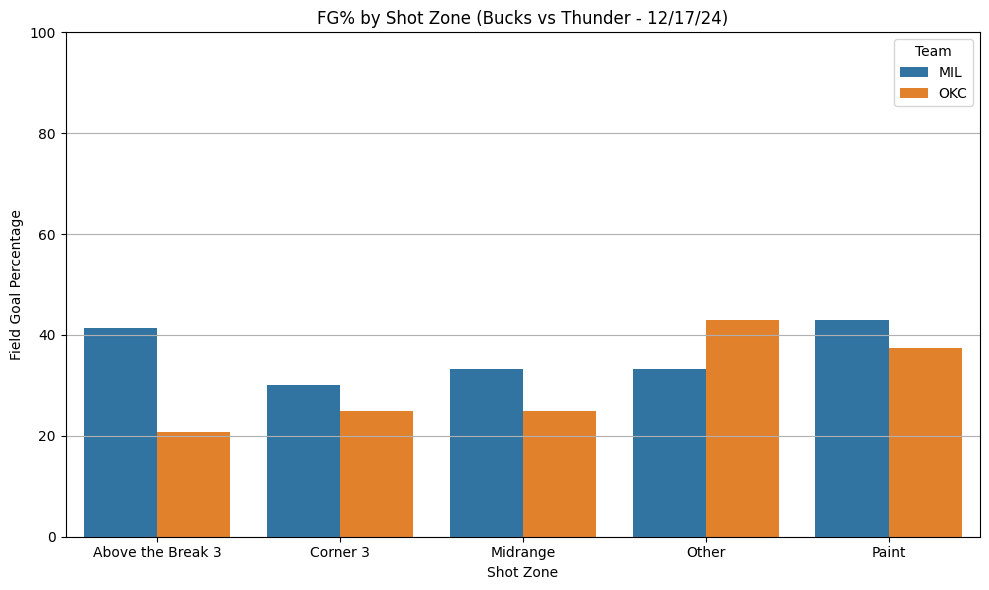

In [6]:
# import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("data_mil_okc_121724_shots.csv")  # Update path if needed

# Step 1: Define Zones
def categorize_shot_zone(row):
    x, y = abs(row['loc_x']), row['loc_y']
    if x <= 8 and y <= 10:
        return 'Paint'
    elif x <= 22 and y <= 14:
        return 'Midrange'
    elif x > 22 and y <= 7:
        return 'Corner 3'
    elif y > 14 and (x**2 + y**2)**0.5 >= 23:
        return 'Above the Break 3'
    else:
        return 'Other'

# Step 2: Apply to DataFrame
df['shot_zone'] = df.apply(categorize_shot_zone, axis=1)

# Step 3: Group by team and zone
zone_summary = df.groupby(['team_nba_off', 'shot_zone']).agg(
    Total_Shots=('fg', 'count'),
    FG_Percentage=('fg', 'mean')
).reset_index()

# Step 4: Format percentages
zone_summary['FG_Percentage'] = (zone_summary['FG_Percentage'] * 100).round(1)

# Step 5: Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=zone_summary, x='shot_zone', y='FG_Percentage', hue='team_nba_off')
plt.title('FG% by Shot Zone (Bucks vs Thunder - 12/17/24)')
plt.ylabel('Field Goal Percentage')
plt.xlabel('Shot Zone')
plt.ylim(0, 100)
plt.legend(title='Team')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()



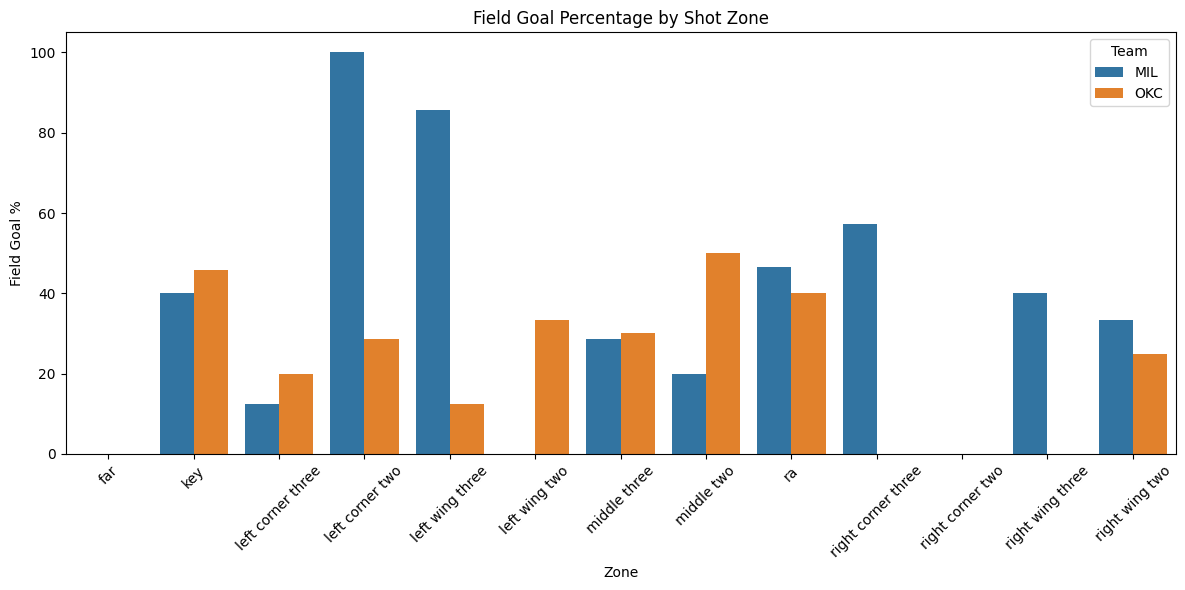

Shot Zone Statistics:
team_nba_off             region  Attempts  Makes    FG%
         MIL                far         2      0   0.00
         MIL                key        15      6  40.00
         MIL  left corner three         8      1  12.50
         MIL    left corner two         2      2 100.00
         MIL    left wing three         7      6  85.71
         MIL      left wing two         2      0   0.00
         MIL       middle three         7      2  28.57
         MIL         middle two         5      1  20.00
         MIL                 ra        15      7  46.67
         MIL right corner three         7      4  57.14
         MIL   right corner two         5      0   0.00
         MIL   right wing three        10      4  40.00
         MIL     right wing two         3      1  33.33
         OKC                key        24     11  45.83
         OKC  left corner three         5      1  20.00
         OKC    left corner two         7      2  28.57
         OKC    left wing 

In [7]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the Data ---
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# --- Analysis Function ---
def analyze_shot_zones(dataframe):
    # Zone-level stats (group by team and region)
    zone_stats = dataframe.groupby(['team_nba_off', 'region']).agg(Attempts=('fg', 'count'),
                                                                    Makes=('fg', 'sum')).reset_index()
    zone_stats['FG%'] = (zone_stats['Makes'] / zone_stats['Attempts']) * 100
    return zone_stats

# --- Run Analysis ---
zone_stats = analyze_shot_zones(df)

# --- Plot Visualization ---
plt.figure(figsize=(12, 6))
sns.barplot(data=zone_stats, x='region', y='FG%', hue='team_nba_off')
plt.title('Field Goal Percentage by Shot Zone')
plt.xticks(rotation=45)
plt.ylabel('Field Goal %')
plt.xlabel('Zone')
plt.legend(title='Team')
plt.tight_layout()
plt.show()

# Print zone statistics
print("\
Shot Zone Statistics:")
print(zone_stats.round(2).to_string(index=False))


  team_nba_off   Avg_qSQ  Actual_FG%
0          MIL  0.496153    0.386364
1          OKC  0.495032    0.308511


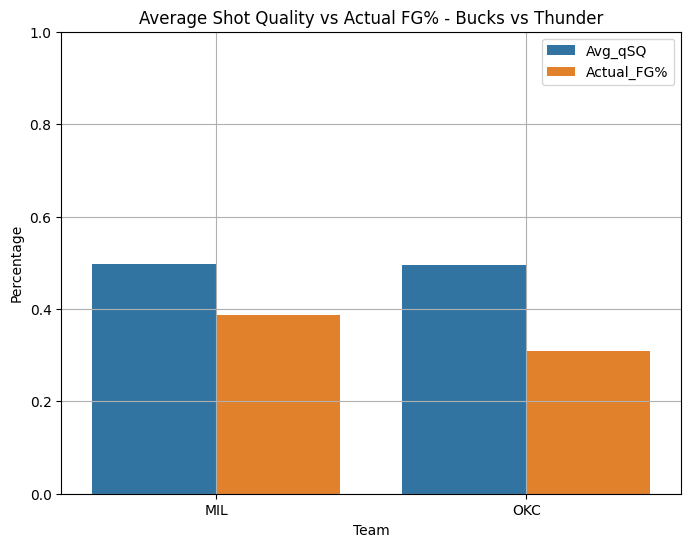

In [8]:
# Fix scaling for qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0  # Rescale qSQ properly

# Now re-calculate averages
team_qsq = df.groupby('team_nba_off')['qSQ'].mean().reset_index()
team_fg = df.groupby('team_nba_off')['fg'].mean().reset_index()

team_summary = pd.merge(team_qsq, team_fg, on='team_nba_off')
team_summary.rename(columns={'qSQ': 'Avg_qSQ', 'fg': 'Actual_FG%'}, inplace=True)

print(team_summary)

# Prepare for plotting
team_summary_melt = team_summary.melt(id_vars='team_nba_off', 
                                      value_vars=['Avg_qSQ', 'Actual_FG%'], 
                                      var_name='Metric', 
                                      value_name='Value')

# Plot again
plt.figure(figsize=(8, 6))
sns.barplot(x='team_nba_off', y='Value', hue='Metric', data=team_summary_melt)
plt.title('Average Shot Quality vs Actual FG% - Bucks vs Thunder')
plt.ylabel('Percentage')
plt.xlabel('Team')
plt.ylim(0, 1)
plt.grid(True)
plt.legend(loc='best')
plt.show()



Top 15 Players by Total Shots:
          player_nba_shooter  Total_Shots  FG_Percentage   Avg_qSQ  \
4   Gilgeous-Alexander, Shai           26       0.307692  0.490150   
0     Antetokounmpo, Giannis           24       0.416667  0.501710   
19           Williams, Jalen           21       0.380952  0.450213   
11           Lillard, Damian           14       0.428571  0.432110   
6        Hartenstein, Isaiah           13       0.461538  0.553578   
12              Lopez, Brook           12       0.416667  0.509390   
14             Portis, Bobby            9       0.222222  0.478945   
16           Trent Jr., Gary            9       0.555556  0.482085   
13            Mitchell, Ajay            7       0.142857  0.503182   
8                Joe, Isaiah            7       0.285714  0.509688   
15           Prince, Taurean            6       0.333333  0.604161   
7         Jackson Jr., Andre            6       0.166667  0.606053   
20         Williams, Kenrich            6       0.166667  0

C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\3228518897.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_qsq,


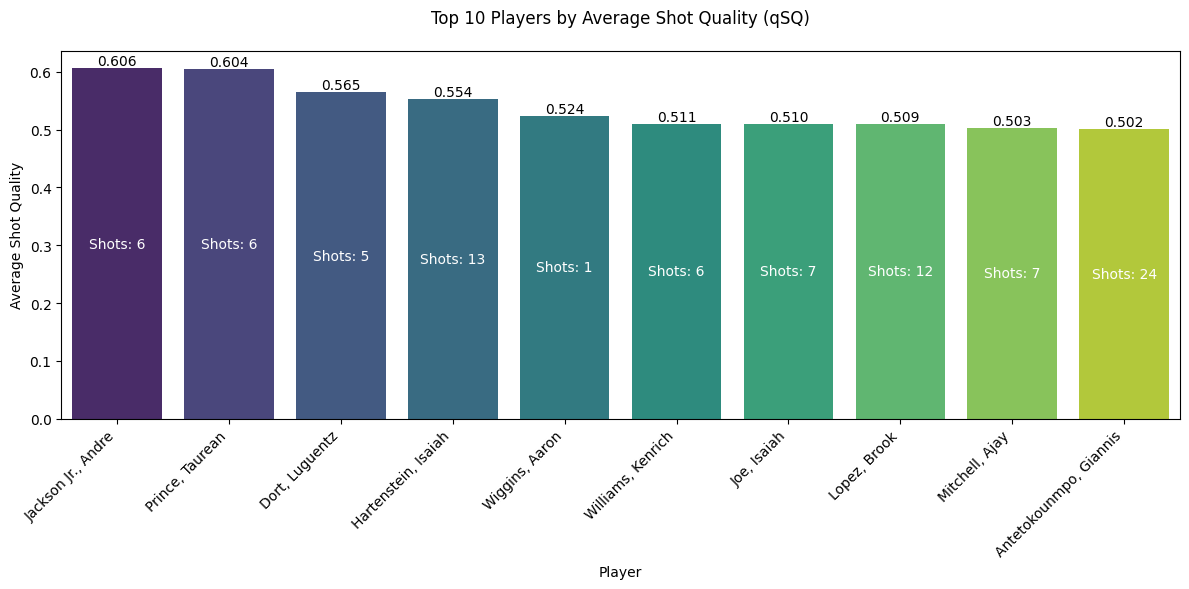

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# 1. Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# 2. Group by player
player_summary = df.groupby('player_nba_shooter').agg(
    Total_Shots=('fg', 'count'),
    FG_Percentage=('fg', 'mean'),
    Avg_qSQ=('qSQ', 'mean'),
    Avg_Distance=('distance', 'mean'),
    Avg_Contest=('closestDefDist', 'mean')
).reset_index()

# 3. Sort by total shots
player_summary = player_summary.sort_values(by='Total_Shots', ascending=False)

# Print summaries
print("Top 15 Players by Total Shots:")
print(player_summary.head(15))

print("\
Top 15 Players by Average Shot Distance:")
top15_distance = player_summary.sort_values(by='Avg_Distance', ascending=False).head(15)
print(top15_distance[['player_nba_shooter', 'Total_Shots', 'Avg_Distance']])

print("\
Top 15 Players by Average Contest Distance:")
top15_contest = player_summary.sort_values(by='Avg_Contest', ascending=False).head(15)
print(top15_contest[['player_nba_shooter', 'Total_Shots', 'Avg_Contest']])

# Create bar plot for top 10 players by shot quality
plt.figure(figsize=(12, 6))
top10_qsq = player_summary.sort_values(by='Avg_qSQ', ascending=False).head(10)

# Create bar plot
sns.barplot(data=top10_qsq, 
            x='player_nba_shooter', 
            y='Avg_qSQ',
            palette='viridis')

# Customize the plot
plt.title('Top 10 Players by Average Shot Quality (qSQ)', pad=20)
plt.xlabel('Player')
plt.ylabel('Average Shot Quality')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(top10_qsq['Avg_qSQ']):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Add number of shots as subtitle for each player
for i, (shots, qsq) in enumerate(zip(top10_qsq['Total_Shots'], top10_qsq['Avg_qSQ'])):
    plt.text(i, qsq/2, f'Shots: {shots}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

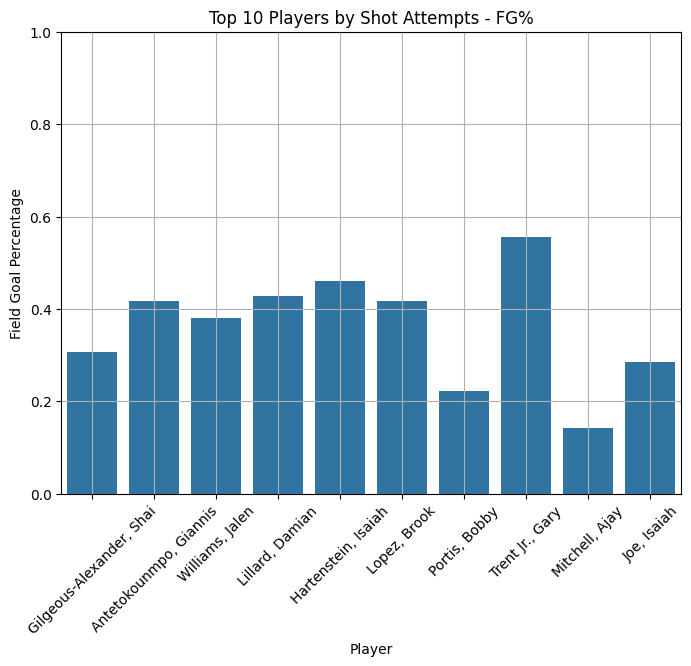

In [10]:
# Top 10 shooters by shot volume
top5_shooters = player_summary.head(10)

# Bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='player_nba_shooter', y='FG_Percentage', data=top5_shooters)
plt.title('Top 10 Players by Shot Attempts - FG%')
plt.ylabel('Field Goal Percentage')
plt.xlabel('Player')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True)
plt.show()


Total Important Shots (Last 4 min Q1-Q2 + Full Q3): 74

Important Time - Team Summary:
  team_nba_off  Total_Important_Shots  Important_FG_Percentage  \
0          MIL                     39                     38.5   
1          OKC                     35                     22.9   

   Avg_Important_qSQ  
0               49.9  
1               46.6  


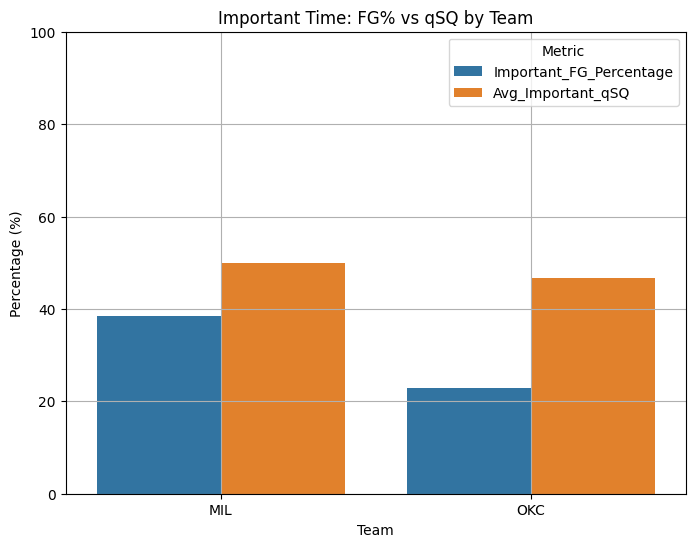


Top Important Time Players (at least 2 shots):
          player_nba_shooter  Total_Important_Shots  Important_FG_Percentage  \
3   Gilgeous-Alexander, Shai                     18                     27.8   
0     Antetokounmpo, Giannis                     15                     33.3   
6         Jackson Jr., Andre                      6                     16.7   
8            Lillard, Damian                      5                     60.0   
14           Williams, Jalen                      5                     40.0   
10             Portis, Bobby                      4                      0.0   
15         Williams, Kenrich                      3                      0.0   
11           Prince, Taurean                      3                     33.3   
5        Hartenstein, Isaiah                      3                      0.0   
1               Caruso, Alex                      2                      0.0   
4                  Green, AJ                      2                     

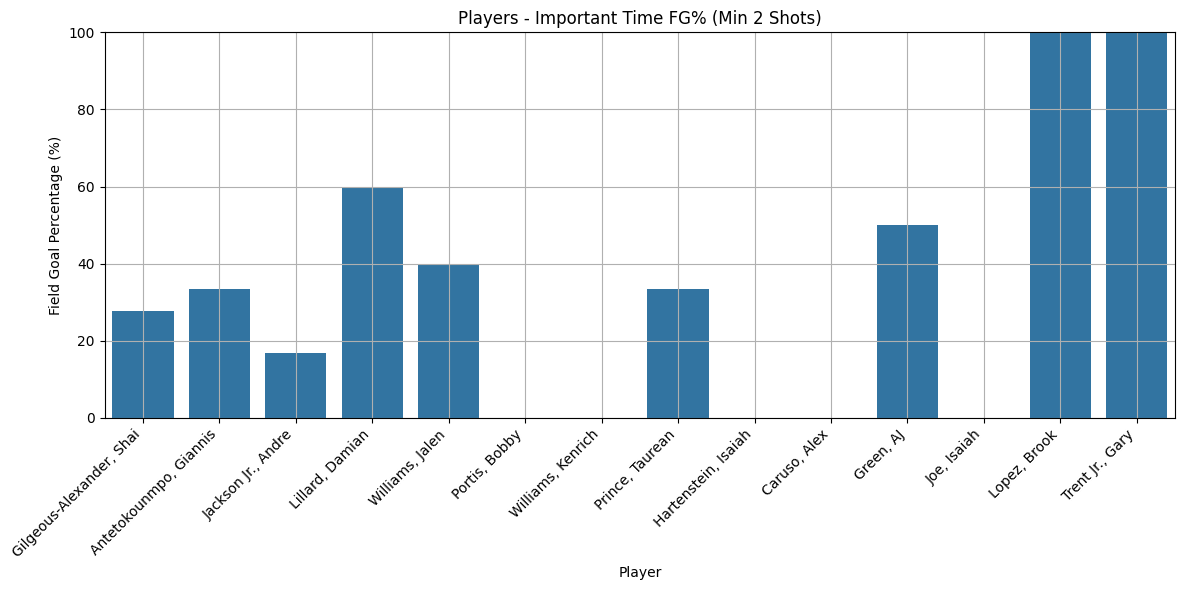

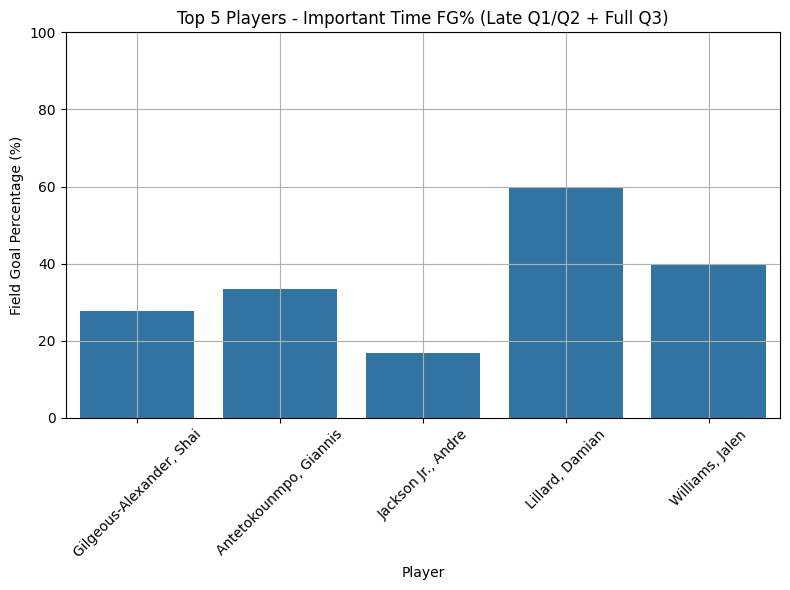

In [11]:
# Imports if needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# Filter: Last 4 minutes of Q1/Q2 and all of Q3
important_shots = df[
    ((df['period'].isin([1, 2])) & (df['gameClock_start'] <= 240)) |
    (df['period'] == 3)
]

print(f"Total Important Shots (Last 4 min Q1-Q2 + Full Q3): {len(important_shots)}")

# Team-level Summary
important_team_summary = important_shots.groupby('team_nba_off').agg(
    Total_Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Avg_Important_qSQ=('qSQ', 'mean')
).reset_index()

# Convert to percent for plot readability
important_team_summary['Important_FG_Percentage'] = (important_team_summary['Important_FG_Percentage'] * 100).round(1)
important_team_summary['Avg_Important_qSQ'] = (important_team_summary['Avg_Important_qSQ'] * 100).round(1)

print("\nImportant Time - Team Summary:")
print(important_team_summary)

# Plot Team-Level Comparison
plt.figure(figsize=(8, 6))
sns.barplot(data=important_team_summary.melt(id_vars='team_nba_off', value_vars=['Important_FG_Percentage', 'Avg_Important_qSQ']),
            x='team_nba_off', y='value', hue='variable')
plt.title('Important Time: FG% vs qSQ by Team')
plt.ylabel('Percentage (%)')
plt.xlabel('Team')
plt.ylim(0, 100)
plt.legend(title='Metric')
plt.grid(True)
plt.show()

# Player-level Summary
important_player_summary = important_shots.groupby('player_nba_shooter').agg(
    Total_Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Avg_Important_qSQ=('qSQ', 'mean')
).reset_index()

# Filter: at least 2 shots
important_player_summary = important_player_summary[important_player_summary['Total_Important_Shots'] >= 2]

# Format as percentage
important_player_summary['Important_FG_Percentage'] = (important_player_summary['Important_FG_Percentage'] * 100).round(1)
important_player_summary['Avg_Important_qSQ'] = (important_player_summary['Avg_Important_qSQ'] * 100).round(1)

# Sort for consistent plotting
important_player_summary = important_player_summary.sort_values(by='Total_Important_Shots', ascending=False)

print("\nTop Important Time Players (at least 2 shots):")
print(important_player_summary[['player_nba_shooter', 'Total_Important_Shots', 'Important_FG_Percentage', 'Avg_Important_qSQ']])

# Bar chart: All players (optional cap for clutter)
plt.figure(figsize=(12, 6))
sns.barplot(x='player_nba_shooter', y='Important_FG_Percentage', data=important_player_summary)
plt.title('Players - Important Time FG% (Min 2 Shots)')
plt.ylabel('Field Goal Percentage (%)')
plt.xlabel('Player')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()

# Top 5 FG% by Total Shots (as before)
top5_important = important_player_summary.head(5)

plt.figure(figsize=(8, 6))
sns.barplot(x='player_nba_shooter', y='Important_FG_Percentage', data=top5_important)
plt.title('Top 5 Players - Important Time FG% (Late Q1/Q2 + Full Q3)')
plt.ylabel('Field Goal Percentage (%)')
plt.xlabel('Player')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


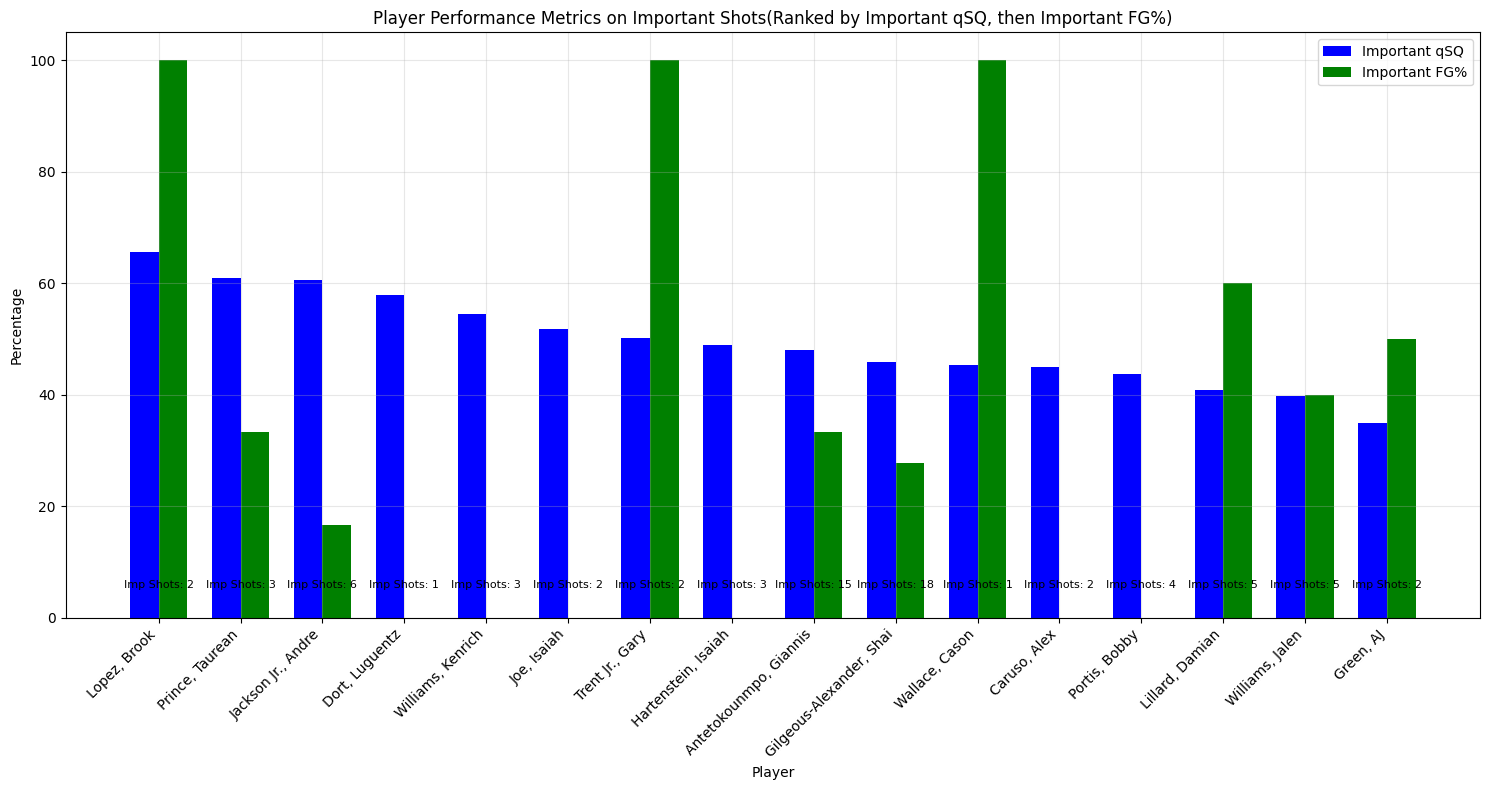

Detailed Player Summary (Ranked by Important qSQ):
          player_nba_shooter  Important_Shots  Important_FG_Percentage  \
9               Lopez, Brook                2                    100.0   
11           Prince, Taurean                3                     33.3   
6         Jackson Jr., Andre                6                     16.7   
2             Dort, Luguentz                1                      0.0   
15         Williams, Kenrich                3                      0.0   
7                Joe, Isaiah                2                      0.0   
12           Trent Jr., Gary                2                    100.0   
5        Hartenstein, Isaiah                3                      0.0   
0     Antetokounmpo, Giannis               15                     33.3   
3   Gilgeous-Alexander, Shai               18                     27.8   
13            Wallace, Cason                1                    100.0   
1               Caruso, Alex                2                

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# Filter important shots (Last 4 minutes of Q1/Q2 and all of Q3)
important_shots = df[
    ((df['period'].isin([1, 2])) & (df['gameClock_start'] <= 240)) |
    (df['period'] == 3)
]

# Player-level summary for important shots
important_player_summary = important_shots.groupby('player_nba_shooter').agg(
    Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Important_Avg_qSQ=('qSQ', 'mean')
).reset_index()

# Convert percentages for better visualization
important_player_summary['Important_FG_Percentage'] *= 100
important_player_summary['Important_Avg_qSQ'] *= 100

# Filter for players with at least 1 important shot
important_player_summary = important_player_summary[important_player_summary['Important_Shots'] > 0]

# Sort by Important qSQ first, then by Important FG%
important_player_summary = important_player_summary.sort_values(
    ['Important_Avg_qSQ', 'Important_FG_Percentage'], 
    ascending=[False, False]
)

# Create visualization
plt.figure(figsize=(15, 8))

# Get all players
x = np.arange(len(important_player_summary))
width = 0.35

# Create bars for Important qSQ and Important FG%
plt.bar(x - width/2, important_player_summary['Important_Avg_qSQ'], 
        width, label='Important qSQ', color='blue')
plt.bar(x + width/2, important_player_summary['Important_FG_Percentage'], 
        width, label='Important FG%', color='green')

# Customize the plot
plt.xlabel('Player')
plt.ylabel('Percentage')
plt.title('Player Performance Metrics on Important Shots\
(Ranked by Important qSQ, then Important FG%)')
plt.xticks(x, important_player_summary['player_nba_shooter'], rotation=45, ha='right')
plt.legend()

# Update the text annotations to better reflect important shot counts
for idx, row in enumerate(important_player_summary.itertuples()):
    plt.text(idx, 5, 'Imp Shots: ' + str(int(row.Important_Shots)), 
             ha='center', va='bottom', fontsize=8, color='black')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed summary
print("\
Detailed Player Summary (Ranked by Important qSQ):")
print(important_player_summary[['player_nba_shooter', 'Important_Shots', 
                               'Important_FG_Percentage', 'Important_Avg_qSQ']].round(1))

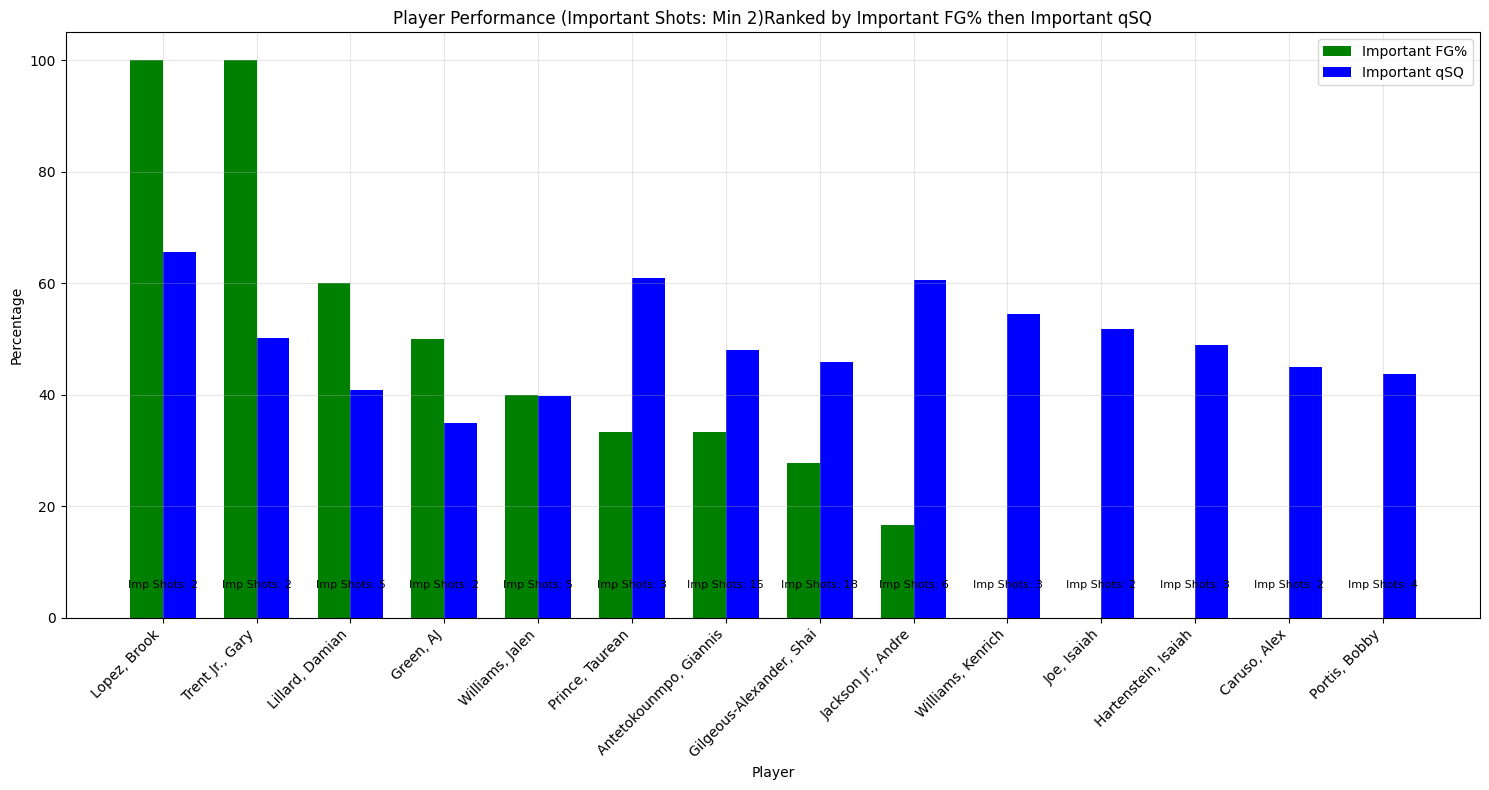

Detailed Player Summary (Min 2 Important Shots, Ranked by FG% then qSQ):
          player_nba_shooter  Important_Shots  Important_FG_Percentage  \
9               Lopez, Brook                2                    100.0   
12           Trent Jr., Gary                2                    100.0   
8            Lillard, Damian                5                     60.0   
4                  Green, AJ                2                     50.0   
14           Williams, Jalen                5                     40.0   
11           Prince, Taurean                3                     33.3   
0     Antetokounmpo, Giannis               15                     33.3   
3   Gilgeous-Alexander, Shai               18                     27.8   
6         Jackson Jr., Andre                6                     16.7   
15         Williams, Kenrich                3                      0.0   
7                Joe, Isaiah                2                      0.0   
5        Hartenstein, Isaiah           

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# Filter important shots (Last 4 minutes of Q1/Q2 and all of Q3)
important_shots = df[((df['period'].isin([1, 2])) & (df['gameClock_start'] <= 240)) | (df['period'] == 3)]

# Player-level summary for important shots
important_player_summary = important_shots.groupby('player_nba_shooter').agg(
    Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Important_Avg_qSQ=('qSQ', 'mean')
).reset_index()

# Convert percentages for visualization
important_player_summary['Important_FG_Percentage'] *= 100
important_player_summary['Important_Avg_qSQ'] *= 100

# Filter for players with at least 2 important shots
important_player_summary = important_player_summary[important_player_summary['Important_Shots'] >= 2]

# Sort by Important FG% first, then by Important qSQ
important_player_summary = important_player_summary.sort_values(
    ['Important_FG_Percentage', 'Important_Avg_qSQ'], 
    ascending=[False, False]
)

# Create visualization
plt.figure(figsize=(15, 8))

x = np.arange(len(important_player_summary))
width = 0.35

plt.bar(x - width/2, important_player_summary['Important_FG_Percentage'], width, label='Important FG%', color='green')
plt.bar(x + width/2, important_player_summary['Important_Avg_qSQ'], width, label='Important qSQ', color='blue')

plt.xlabel('Player')
plt.ylabel('Percentage')
plt.title('Player Performance (Important Shots: Min 2)\
Ranked by Important FG% then Important qSQ')
plt.xticks(x, important_player_summary['player_nba_shooter'], rotation=45, ha='right')
plt.legend()

# Add text annotations for shot counts
for idx, row in enumerate(important_player_summary.itertuples()):
    plt.text(idx, 5, 'Imp Shots: ' + str(int(row.Important_Shots)), ha='center', va='bottom', fontsize=8, color='black')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\
Detailed Player Summary (Min 2 Important Shots, Ranked by FG% then qSQ):")
print(important_player_summary[['player_nba_shooter', 'Important_Shots', 'Important_FG_Percentage', 'Important_Avg_qSQ']].round(1))

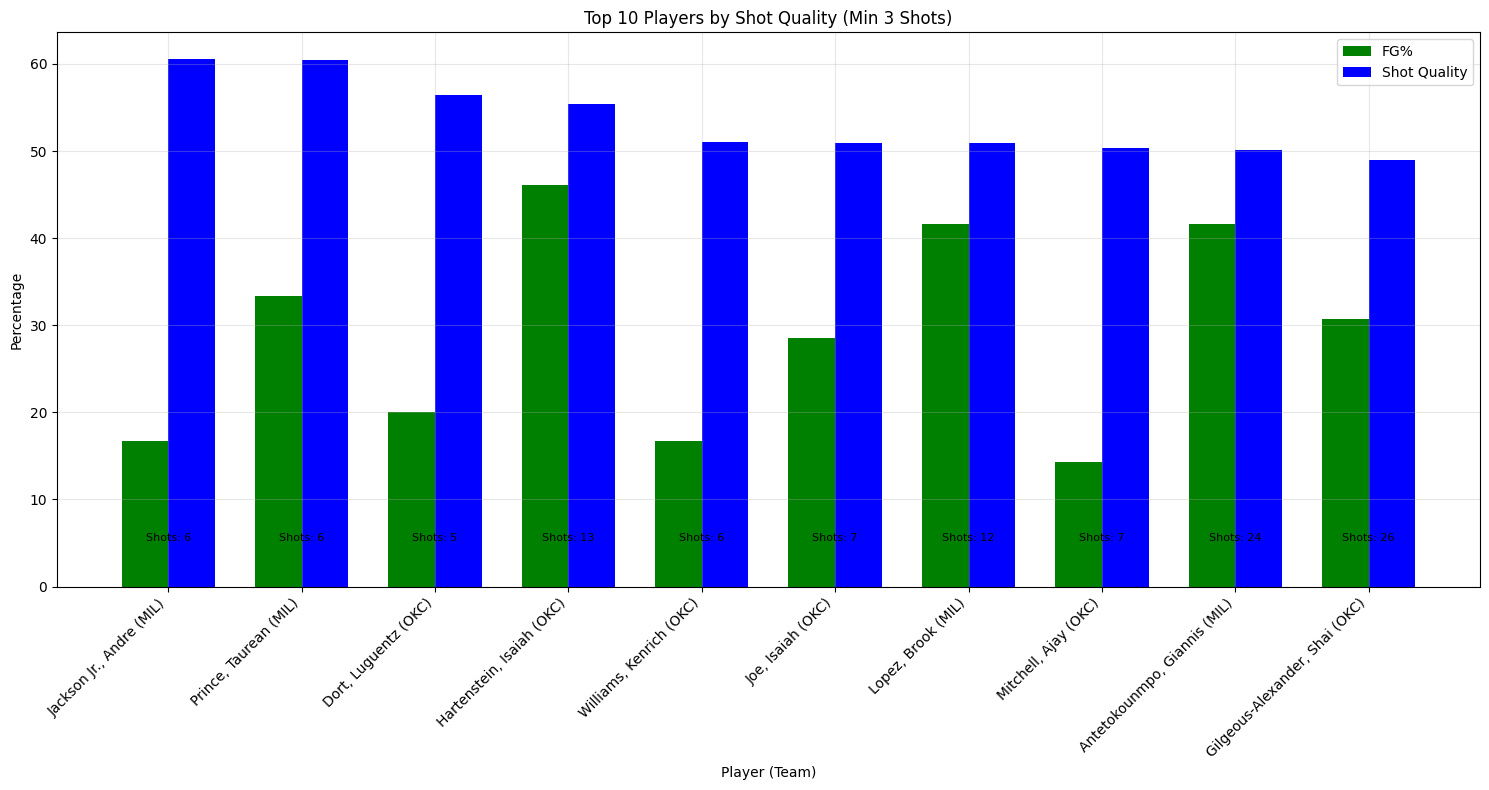

Detailed Top 10 Player Summary (Sorted by Shot Quality):
                             Label  Total_Shots  FG_Percentage  Avg_qSQ
3         Jackson Jr., Andre (MIL)            6           16.7     60.6
8            Prince, Taurean (MIL)            6           33.3     60.4
11            Dort, Luguentz (OKC)            5           20.0     56.5
13       Hartenstein, Isaiah (OKC)           13           46.2     55.4
20         Williams, Kenrich (OKC)            6           16.7     51.1
14               Joe, Isaiah (OKC)            7           28.6     51.0
6               Lopez, Brook (MIL)           12           41.7     50.9
16            Mitchell, Ajay (OKC)            7           14.3     50.3
0     Antetokounmpo, Giannis (MIL)           24           41.7     50.2
12  Gilgeous-Alexander, Shai (OKC)           26           30.8     49.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# Player-level summary for overall shot quality and FG%
overall_player_summary = df.groupby(['team_nba_off', 'player_nba_shooter']).agg(
    Total_Shots=('fg', 'count'),
    FG_Percentage=('fg', 'mean'),
    Avg_qSQ=('qSQ', 'mean')
).reset_index()

# Convert percentages for visualization
overall_player_summary['Avg_qSQ'] *= 100
overall_player_summary['FG_Percentage'] *= 100

# Filter for players with at least 3 shots
overall_player_summary = overall_player_summary[overall_player_summary['Total_Shots'] >= 3]

# Create combined label "name (team)"
overall_player_summary['Label'] = overall_player_summary['player_nba_shooter'] + ' (' + overall_player_summary['team_nba_off'] + ')'

# Sort by average shot quality (descending) and take top 10
top10_overall = overall_player_summary.sort_values('Avg_qSQ', ascending=False).head(10)

# Create visualization
plt.figure(figsize=(15, 8))
x = np.arange(len(top10_overall))
width = 0.35

# Plot bars
plt.bar(x - width/2, top10_overall['FG_Percentage'], width, label='FG%', color='green')
plt.bar(x + width/2, top10_overall['Avg_qSQ'], width, label='Shot Quality', color='blue')

plt.xlabel('Player (Team)')
plt.ylabel('Percentage')
plt.title('Top 10 Players by Shot Quality (Min 3 Shots)')
plt.xticks(x, top10_overall['Label'], rotation=45, ha='right')
plt.legend()

# Add shot count annotations
for idx, row in enumerate(top10_overall.itertuples()):
    plt.text(idx, 5, 'Shots: ' + str(int(row.Total_Shots)), ha='center', va='bottom', fontsize=8, color='black')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Detailed Top 10 Player Summary (Sorted by Shot Quality):")
print(top10_overall[['Label', 'Total_Shots', 'FG_Percentage', 'Avg_qSQ']].round(1))

Total Important Shots (Last 4 min Q1-Q2 + Full Q3): 74

Important Time - Team Summary:
  team_nba_off  Total_Important_Shots  Important_FG_Percentage  \
0          MIL                     39                 0.384615   
1          OKC                     35                 0.228571   

   Avg_Important_qSQ  
0           0.499335  
1           0.466120  

Top Important Time Players (at least 2 shots):
          player_nba_shooter  Total_Important_Shots  Important_FG_Percentage  \
3   Gilgeous-Alexander, Shai                     18                     27.8   
0     Antetokounmpo, Giannis                     15                     33.3   
6         Jackson Jr., Andre                      6                     16.7   
8            Lillard, Damian                      5                     60.0   
14           Williams, Jalen                      5                     40.0   
10             Portis, Bobby                      4                      0.0   
15         Williams, Kenrich         

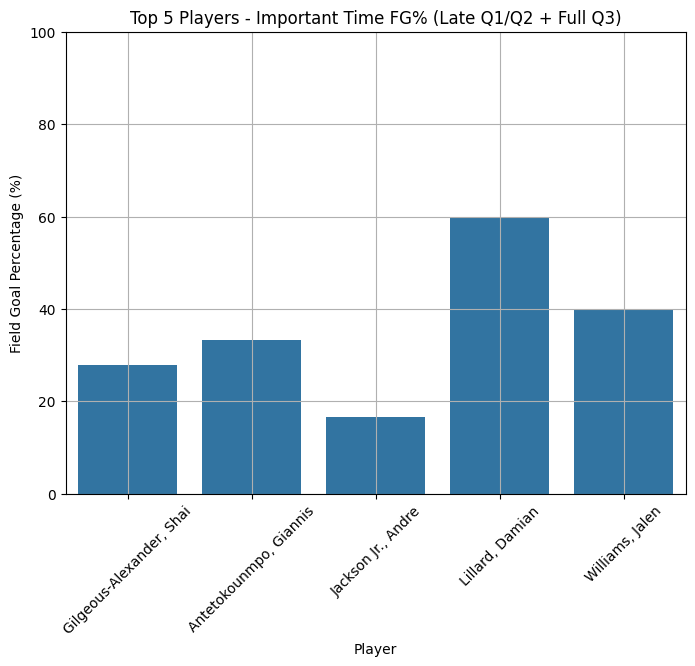

In [15]:
# Imports if needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Normalize qSQ if needed
if df['qSQ'].max() > 1.0:
    df['qSQ'] = df['qSQ'] / 100.0

# 2. Filter:
# - Last 4 minutes of Q1 and Q2
# - All of Q3
important_shots = df[
    ((df['period'].isin([1, 2])) & (df['gameClock_start'] <= 240)) |
    (df['period'] == 3)
]

print(f"Total Important Shots (Last 4 min Q1-Q2 + Full Q3): {len(important_shots)}")

# 3. Team-level Summary
important_team_summary = important_shots.groupby('team_nba_off').agg(
    Total_Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Avg_Important_qSQ=('qSQ', 'mean')
).reset_index()

print("\nImportant Time - Team Summary:")
print(important_team_summary)

# 4. Player-level Summary (including player name)
important_player_summary = important_shots.groupby('player_nba_shooter').agg(
    Total_Important_Shots=('fg', 'count'),
    Important_FG_Percentage=('fg', 'mean'),
    Avg_Important_qSQ=('qSQ', 'mean')
).reset_index()

# Keep players with at least 2 shots
important_player_summary = important_player_summary[important_player_summary['Total_Important_Shots'] >= 2]

# Sort by total shots descending
important_player_summary = important_player_summary.sort_values(by='Total_Important_Shots', ascending=False)

# Reformat FG% and qSQ to show clean percentages if you want (optional)
important_player_summary['Important_FG_Percentage'] = (important_player_summary['Important_FG_Percentage'] * 100).round(1)
important_player_summary['Avg_Important_qSQ'] = (important_player_summary['Avg_Important_qSQ'] * 100).round(1)

print("\nTop Important Time Players (at least 2 shots):")
print(important_player_summary[['player_nba_shooter', 'Total_Important_Shots', 'Important_FG_Percentage', 'Avg_Important_qSQ']])

# 5. (Optional) Plot top 5 players by Important FG%
top5_important = important_player_summary.head(5)

plt.figure(figsize=(8, 6))
sns.barplot(x='player_nba_shooter', y='Important_FG_Percentage', data=top5_important)
plt.title('Top 5 Players - Important Time FG% (Late Q1/Q2 + Full Q3)')
plt.ylabel('Field Goal Percentage (%)')
plt.xlabel('Player')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()





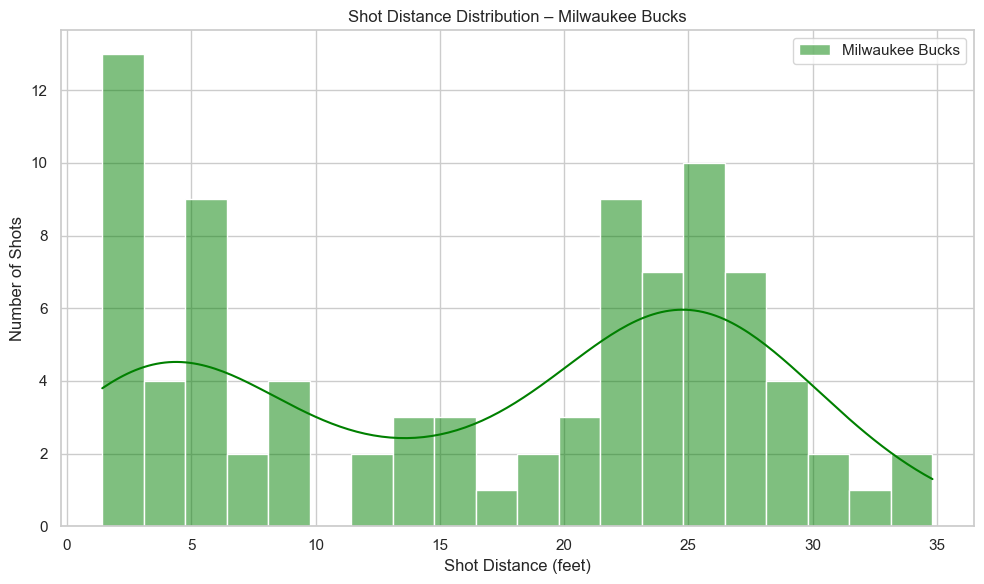

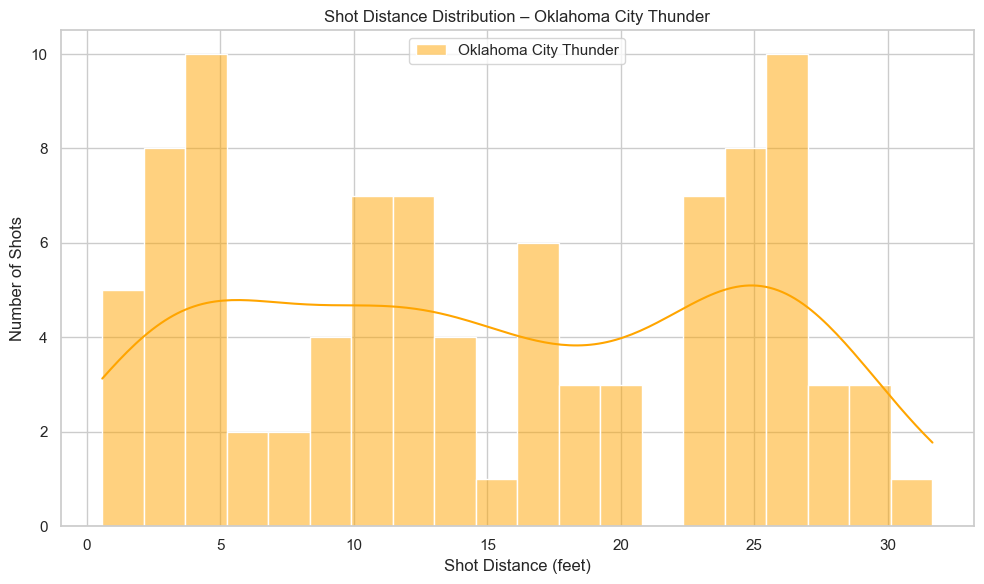

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data if needed
# df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Set seaborn style
sns.set(style='whitegrid')

# --- Milwaukee Bucks ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df['team_nba_off'] == 'MIL'],
    x='distance',
    bins=20,
    color='green',
    kde=True,
    label='Milwaukee Bucks'
)
plt.title('Shot Distance Distribution – Milwaukee Bucks')
plt.xlabel('Shot Distance (feet)')
plt.ylabel('Number of Shots')
plt.legend()
plt.tight_layout()
plt.show()

# --- Oklahoma City Thunder ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df['team_nba_off'] == 'OKC'],
    x='distance',
    bins=20,
    color='orange',
    kde=True,
    label='Oklahoma City Thunder'
)
plt.title('Shot Distance Distribution – Oklahoma City Thunder')
plt.xlabel('Shot Distance (feet)')
plt.ylabel('Number of Shots')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Define off-dribble shots (example: more than 1 dribble = off-dribble)
df['off_dribble'] = df['dribblesBefore'] > 1

# Ball Movement Summary
ball_movement_summary = df.groupby('team_nba_off')['off_dribble'].mean().reset_index()
ball_movement_summary['Off-Dribble Shot %'] = (ball_movement_summary['off_dribble'] * 100).round(1)
print(ball_movement_summary[['team_nba_off', 'Off-Dribble Shot %']])


  team_nba_off  Off-Dribble Shot %
0          MIL                33.0
1          OKC                53.2


In [18]:
# Filter 3rd quarter shots
third_qtr_shots = df[df['period'] == 3]

# Top scorers by shots made
top_scorers_q3 = third_qtr_shots.groupby('player_nba_shooter').agg(
    Total_Shots=('fg', 'count'),
    FG_Percentage=('fg', 'mean')
).reset_index().sort_values(by='Total_Shots', ascending=False)

# Optional: clean up FG% to percentage
top_scorers_q3['FG_Percentage'] = (top_scorers_q3['FG_Percentage'] * 100).round(1)

print(top_scorers_q3.head(10))


          player_nba_shooter  Total_Shots  FG_Percentage
0     Antetokounmpo, Giannis           12           33.3
3   Gilgeous-Alexander, Shai            9           33.3
7            Lillard, Damian            4           50.0
13         Williams, Kenrich            3            0.0
6         Jackson Jr., Andre            3            0.0
9            Prince, Taurean            3           33.3
12           Williams, Jalen            3           33.3
5        Hartenstein, Isaiah            2            0.0
1               Caruso, Alex            1            0.0
2             Dort, Luguentz            1            0.0


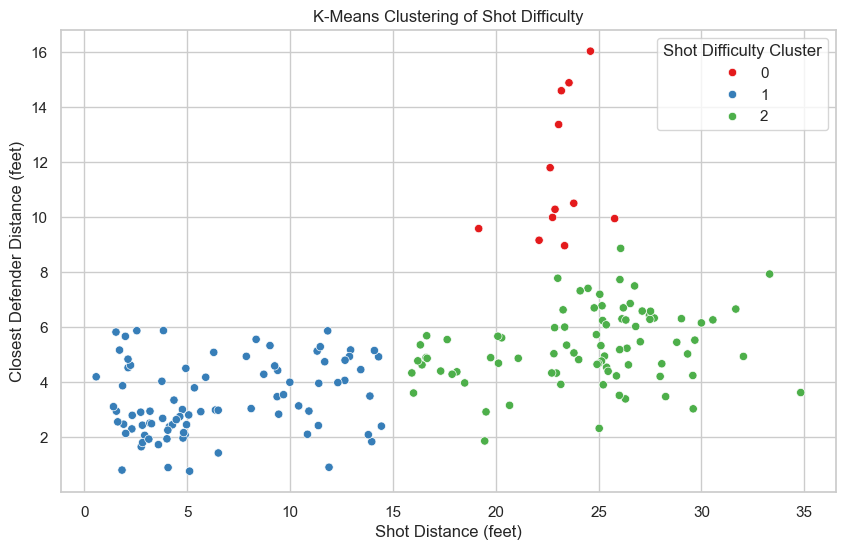


Cluster Centers (Average Distance and Contest):
    distance  closestDefDist
0  23.073465       11.596774
1   6.550756        3.382018
2  24.371578        5.294034


In [19]:
# --- Correct Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. Select Features for Clustering ---
cluster_features = df[['distance', 'closestDefDist']].copy()
cluster_features = cluster_features.dropna()

# --- 2. Apply KMeans Clustering ---
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(cluster_features)

# --- 3. Assign Cluster Labels to Data ---
cluster_features['Cluster'] = kmeans.labels_

# --- 4. Plot the Clusters ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_features, 
    x='distance', 
    y='closestDefDist', 
    hue='Cluster', 
    palette='Set1'
)
plt.title('K-Means Clustering of Shot Difficulty')
plt.xlabel('Shot Distance (feet)')
plt.ylabel('Closest Defender Distance (feet)')
plt.legend(title='Shot Difficulty Cluster')
plt.grid(True)
plt.show()

# --- 5. View Cluster Centers ---
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['distance', 'closestDefDist'])
print("\nCluster Centers (Average Distance and Contest):")
print(centers)


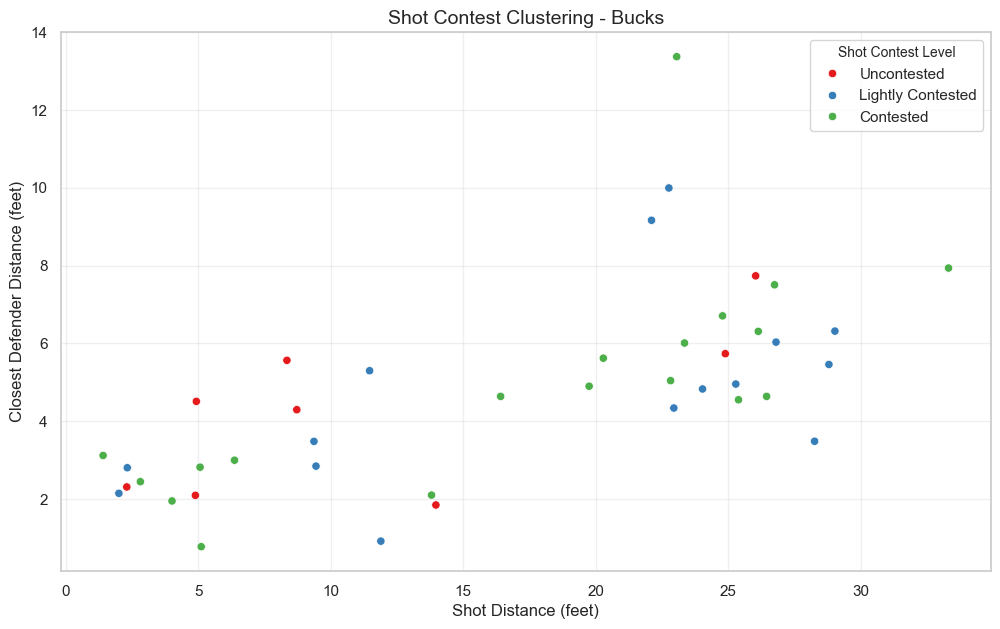

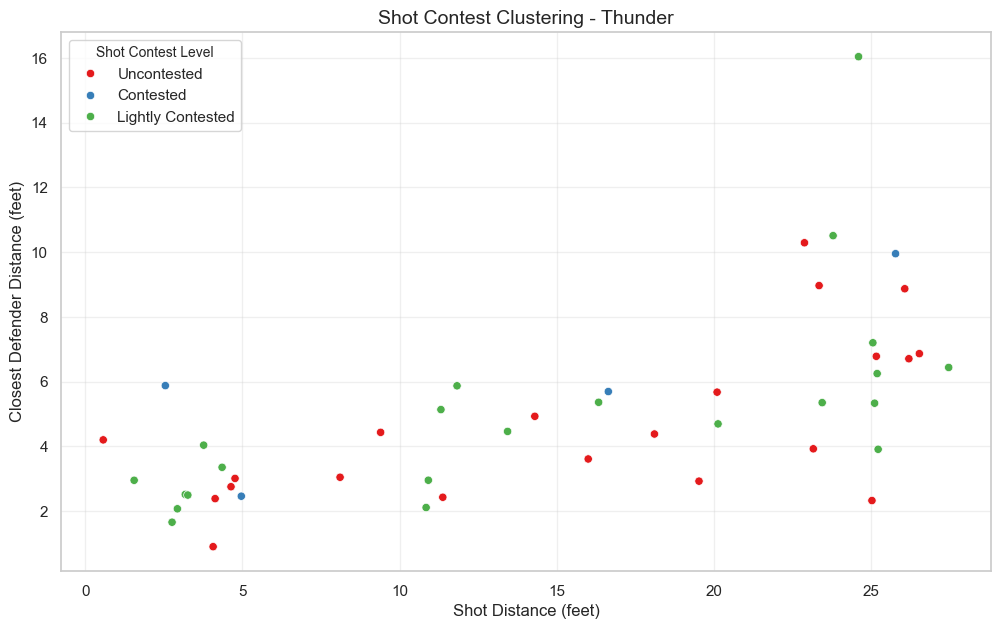

Bucks Cluster Centers (distance, defender distance):
Contested: [26.1   6.17]
Lightly Contested: [4.34 3.05]
Uncontested: [16.66  3.64]
Thunder Cluster Centers (distance, defender distance):
Contested: [23.6  11.52]
Lightly Contested: [7.33 3.69]
Uncontested: [23.55  5.07]


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Load data if not already loaded
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Select features
cluster_features_full = df[['distance', 'closestDefDist', 'team_nba_off']].copy()
cluster_features_full = cluster_features_full.dropna()

# Create a mapping dictionary for cluster labels
cluster_map = {0: 'Contested', 1: 'Lightly Contested', 2: 'Uncontested'}

# --- Bucks Data ---
bucks_shots = cluster_features_full[cluster_features_full['team_nba_off'] == 'MIL'][['distance', 'closestDefDist']]

# Apply KMeans to Bucks
kmeans_bucks = KMeans(n_clusters=3, random_state=42)
kmeans_bucks.fit(bucks_shots)

# Add Cluster Labels and map to descriptive names
bucks_shots['Shot Contest'] = pd.Series(kmeans_bucks.labels_).map(cluster_map)

# Plot Bucks Clustering
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=bucks_shots, 
    x='distance', 
    y='closestDefDist', 
    hue='Shot Contest', 
    palette='Set1'
)
plt.title('Shot Contest Clustering - Bucks', fontsize=14)
plt.xlabel('Shot Distance (feet)', fontsize=12)
plt.ylabel('Closest Defender Distance (feet)', fontsize=12)
plt.legend(title='Shot Contest Level', title_fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# --- Thunder Data ---
thunder_shots = cluster_features_full[cluster_features_full['team_nba_off'] == 'OKC'][['distance', 'closestDefDist']]

# Apply KMeans to Thunder
kmeans_thunder = KMeans(n_clusters=3, random_state=42)
kmeans_thunder.fit(thunder_shots)

# Add Cluster Labels and map to descriptive names
thunder_shots['Shot Contest'] = pd.Series(kmeans_thunder.labels_).map(cluster_map)

# Plot Thunder Clustering
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=thunder_shots, 
    x='distance', 
    y='closestDefDist', 
    hue='Shot Contest', 
    palette='Set1'
)
plt.title('Shot Contest Clustering - Thunder', fontsize=14)
plt.xlabel('Shot Distance (feet)', fontsize=12)
plt.ylabel('Closest Defender Distance (feet)', fontsize=12)
plt.legend(title='Shot Contest Level', title_fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Print cluster centers to understand the characteristics of each group
print("\
Bucks Cluster Centers (distance, defender distance):")
for i, center in enumerate(kmeans_bucks.cluster_centers_):
    print(f"{cluster_map[i]}: {center.round(2)}")

print("\
Thunder Cluster Centers (distance, defender distance):")
for i, center in enumerate(kmeans_thunder.cluster_centers_):
    print(f"{cluster_map[i]}: {center.round(2)}")

In [21]:
# Add team names back to the clustered data
cluster_features['team_nba_off'] = df.loc[cluster_features.index, 'team_nba_off']

# Count number of shots by team and cluster
team_cluster_counts = cluster_features.groupby(['team_nba_off', 'Cluster']).size().reset_index(name='Shot_Count')

print("\nShots per Team per Cluster:")
print(team_cluster_counts)

# (Optional) Pivot table for easier view
pivot_table = team_cluster_counts.pivot(index='team_nba_off', columns='Cluster', values='Shot_Count').fillna(0)
pivot_table.columns = ['Cluster 0 (Easy)', 'Cluster 1 (Medium)', 'Cluster 2 (Hard)']
pivot_table = pivot_table.astype(int)

print("\nPivot Table (Shots by Difficulty Cluster):")
print(pivot_table)



Shots per Team per Cluster:
  team_nba_off  Cluster  Shot_Count
0          MIL        0           4
1          MIL        1          37
2          MIL        2          47
3          OKC        0           8
4          OKC        1          49
5          OKC        2          37

Pivot Table (Shots by Difficulty Cluster):
              Cluster 0 (Easy)  Cluster 1 (Medium)  Cluster 2 (Hard)
team_nba_off                                                        
MIL                          4                  37                47
OKC                          8                  49                37


C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\572647279.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_stats = df.groupby(['team_nba_off', 'distance_bin']).agg({'fg': ['count', 'mean']}).reset_index()


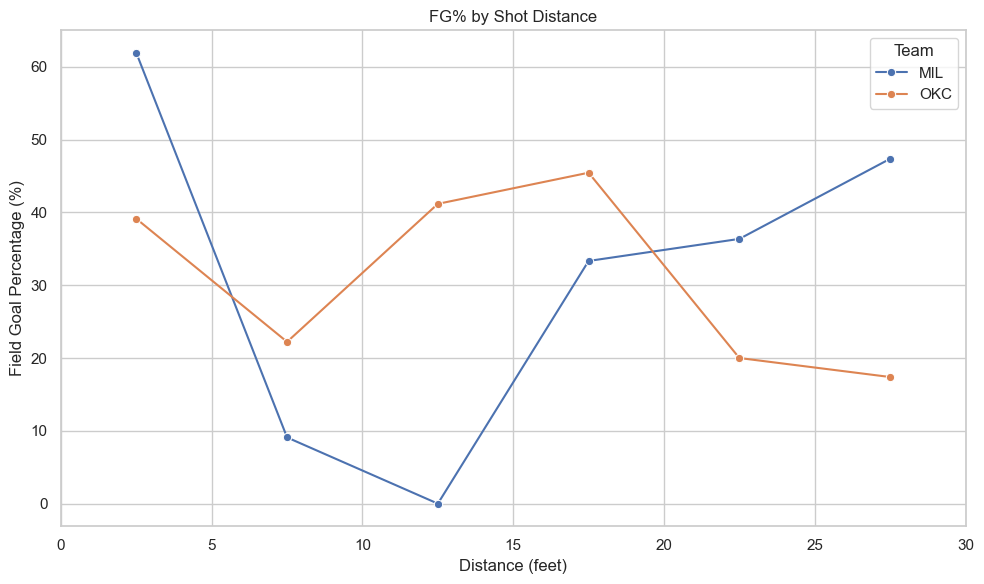

C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\572647279.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  angle_stats = df.groupby(['team_nba_off', 'angle_bin']).agg({'fg': ['count', 'mean']}).reset_index()


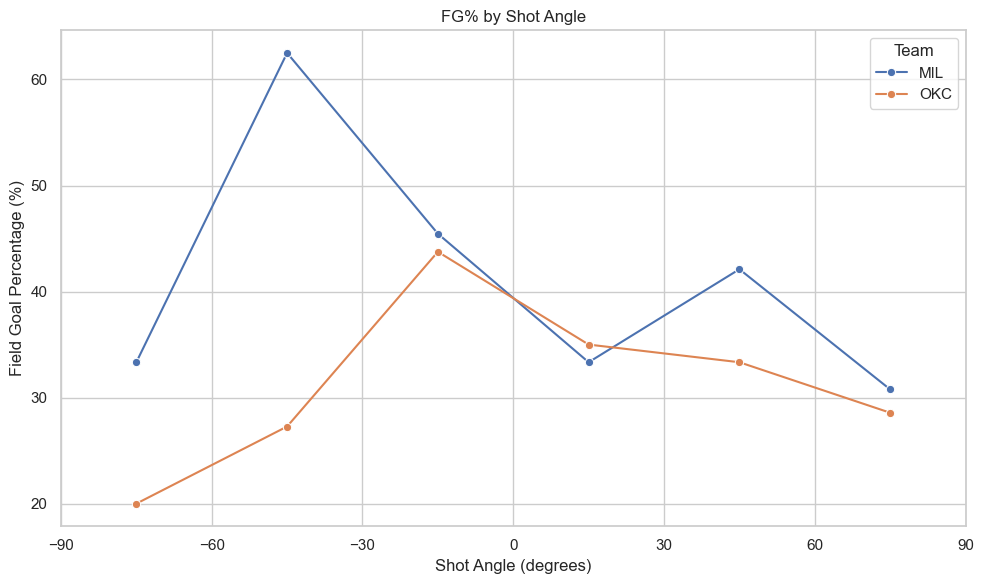

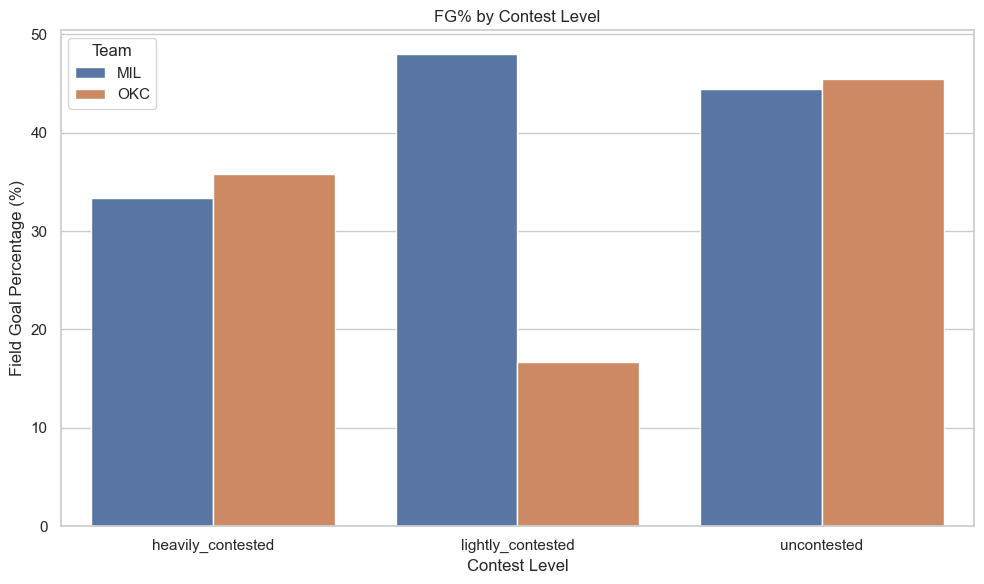

C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\572647279.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def_dist_stats = df.groupby(['team_nba_off', 'def_dist_bin']).agg({'fg': ['count', 'mean']}).reset_index()


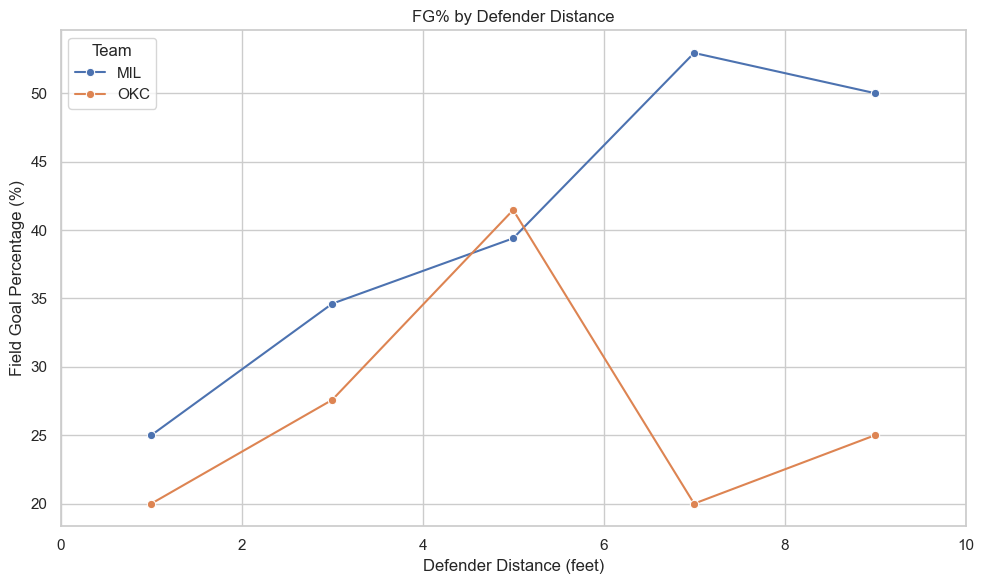

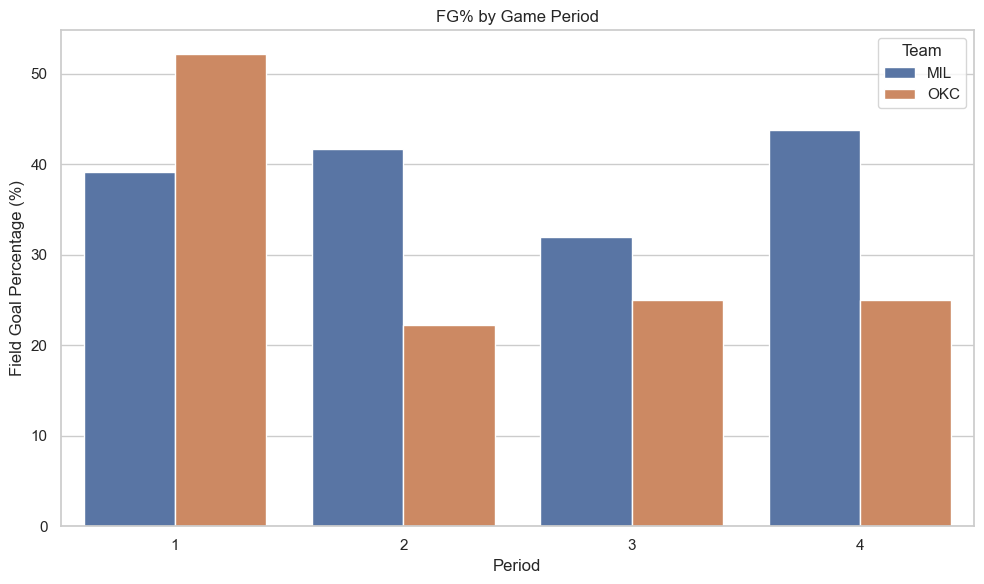

C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\572647279.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucks_player, x='FG%', y='Player', palette='Blues_d')
C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\572647279.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=thunder_player, x='FG%', y='Player', palette='Reds_d')


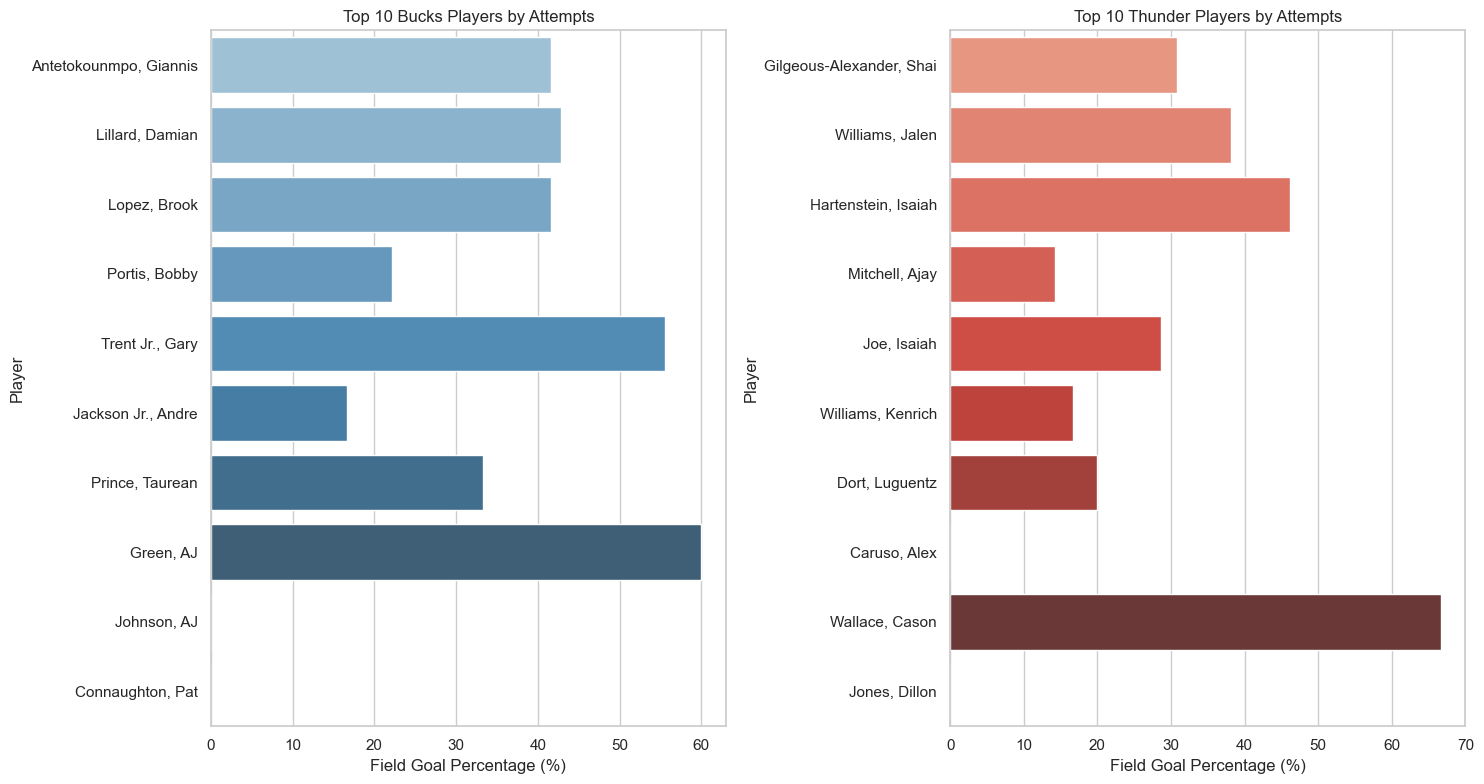

Shot Distance Analysis:
MIL Average Shot Distance: 16.7 feet
OKC Average Shot Distance: 15.1 feet


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# 1. Shot Distance vs FG%
# Create bins for distance in 5-feet increments up to 35
distance_bins = np.arange(0, 35, 5)
df['distance_bin'] = pd.cut(df['distance'], bins=distance_bins, right=False)

distance_stats = df.groupby(['team_nba_off', 'distance_bin']).agg({'fg': ['count', 'mean']}).reset_index()
distance_stats.columns = ['Team', 'DistanceBin', 'Attempts', 'FG%']
# Convert FG% to percentage
distance_stats['FG%'] = distance_stats['FG%'] * 100
# Convert distance bin to its midpoint for plotting
distance_stats['Distance_mid'] = distance_stats['DistanceBin'].apply(lambda x: x.left + (x.right - x.left)/2 if pd.notnull(x) else np.nan)

# Plot FG% by Shot Distance using midpoints
plt.figure(figsize=(10, 6))
sns.lineplot(data=distance_stats, x='Distance_mid', y='FG%', hue='Team', marker='o')
plt.title('FG% by Shot Distance')
plt.xlabel('Distance (feet)')
plt.ylabel('Field Goal Percentage (%)')
plt.xticks(distance_bins)
plt.tight_layout()
plt.show()

# 2. Shot Angle vs FG%
# Create bins for shot angle from -90 to 90 (in 30 degree increments)
angle_bins = np.arange(-90, 91, 30)
df['angle_bin'] = pd.cut(df['shotAngle'], bins=angle_bins, right=False)

angle_stats = df.groupby(['team_nba_off', 'angle_bin']).agg({'fg': ['count', 'mean']}).reset_index()
angle_stats.columns = ['Team', 'AngleBin', 'Attempts', 'FG%']
angle_stats['FG%'] = angle_stats['FG%'] * 100
angle_stats['Angle_mid'] = angle_stats['AngleBin'].apply(lambda x: x.left + (x.right - x.left)/2 if pd.notnull(x) else np.nan)

plt.figure(figsize=(10, 6))
sns.lineplot(data=angle_stats, x='Angle_mid', y='FG%', hue='Team', marker='o')
plt.title('FG% by Shot Angle')
plt.xlabel('Shot Angle (degrees)')
plt.ylabel('Field Goal Percentage (%)')
plt.xticks(angle_bins)
plt.tight_layout()
plt.show()

# 3. Defensive Pressure Analysis
# a. Contest Level Analysis (bar plot)
contest_stats = df.groupby(['team_nba_off', 'contestLevel']).agg({'fg': ['count', 'mean']}).reset_index()
contest_stats.columns = ['Team', 'ContestLevel', 'Attempts', 'FG%']
contest_stats['FG%'] = contest_stats['FG%'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=contest_stats, x='ContestLevel', y='FG%', hue='Team')
plt.title('FG% by Contest Level')
plt.xlabel('Contest Level')
plt.ylabel('Field Goal Percentage (%)')
plt.tight_layout()
plt.show()

# b. Defender Distance Analysis
# Create bins for closestDefDist in 2 feet increments up to 10 feet
def_dist_bins = np.arange(0, 12, 2)
df['def_dist_bin'] = pd.cut(df['closestDefDist'], bins=def_dist_bins, right=False)

def_dist_stats = df.groupby(['team_nba_off', 'def_dist_bin']).agg({'fg': ['count', 'mean']}).reset_index()
def_dist_stats.columns = ['Team', 'DefDistBin', 'Attempts', 'FG%']
def_dist_stats['FG%'] = def_dist_stats['FG%'] * 100
# Compute midpoints
def_dist_stats['DefDist_mid'] = def_dist_stats['DefDistBin'].apply(lambda x: x.left + (x.right - x.left)/2 if pd.notnull(x) else np.nan)

plt.figure(figsize=(10, 6))
sns.lineplot(data=def_dist_stats, x='DefDist_mid', y='FG%', hue='Team', marker='o')
plt.title('FG% by Defender Distance')
plt.xlabel('Defender Distance (feet)')
plt.ylabel('Field Goal Percentage (%)')
plt.xticks(def_dist_bins)
plt.tight_layout()
plt.show()

# 4. Temporal Trends Beyond Clutch Moments
# Assuming game segments based on period
period_stats = df.groupby(['team_nba_off', 'period']).agg({'fg': ['count', 'mean']}).reset_index()
period_stats.columns = ['Team', 'Period', 'Attempts', 'FG%']
period_stats['FG%'] = period_stats['FG%'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=period_stats, x='Period', y='FG%', hue='Team')
plt.title('FG% by Game Period')
plt.xlabel('Period')
plt.ylabel('Field Goal Percentage (%)')
plt.tight_layout()
plt.show()

# 5. Player-Specific Analysis
# Let's analyze average FG% and attempts for each player
player_stats = df.groupby(['team_nba_off', 'player_nba_shooter']).agg({'fg': ['count', 'mean']}).reset_index()
player_stats.columns = ['Team', 'Player', 'Attempts', 'FG%']
player_stats['FG%'] = player_stats['FG%'] * 100

plt.figure(figsize=(15, 8))
# For Bucks
bucks_player = player_stats[player_stats['Team'] == 'MIL'].sort_values('Attempts', ascending=False).head(10)
plt.subplot(1, 2, 1)
sns.barplot(data=bucks_player, x='FG%', y='Player', palette='Blues_d')
plt.title('Top 10 Bucks Players by Attempts')
plt.xlabel('Field Goal Percentage (%)')

# For Thunder
thunder_player = player_stats[player_stats['Team'] == 'OKC'].sort_values('Attempts', ascending=False).head(10)
plt.subplot(1, 2, 2)
sns.barplot(data=thunder_player, x='FG%', y='Player', palette='Reds_d')
plt.title('Top 10 Thunder Players by Attempts')
plt.xlabel('Field Goal Percentage (%)')

plt.tight_layout()
plt.show()

# Print summary statistics for shot distance and defensive pressure
print("\
Shot Distance Analysis:")
for team in ['MIL', 'OKC']:
    avg_distance = df[df['team_nba_off'] == team]['distance'].mean()
    print(f"{team} Average Shot Distance: {avg_distance:.1f} feet")




C:\Users\sonia\AppData\Local\Temp\ipykernel_24504\2327461742.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def_pressure_stats = df.groupby(['team_nba_off', 'contestLevel', 'def_distance_bin']).agg({


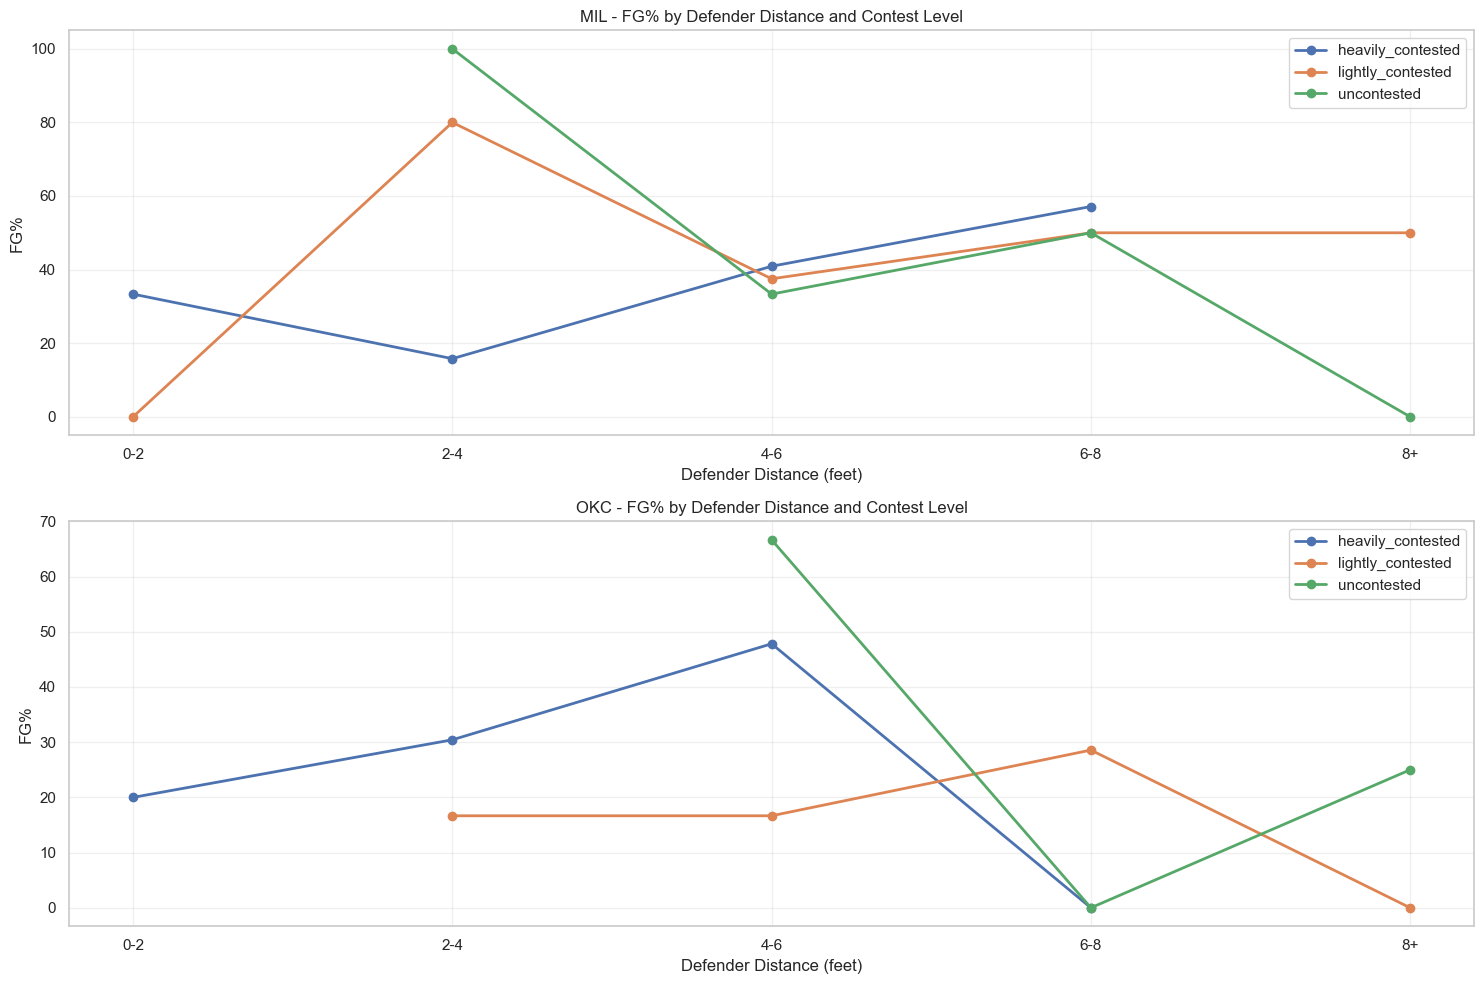

Detailed Defensive Pressure Analysis:
Breakdown by Contest Level and Defender Distance:
Team     Contest_Level Defender_Distance  Attempts  Makes   FG%
 MIL heavily_contested               0-2         6      2  33.3
 MIL heavily_contested               2-4        19      3  15.8
 MIL heavily_contested               4-6        22      9  40.9
 MIL heavily_contested               6-8         7      4  57.1
 MIL heavily_contested                8+         0      0   NaN
 MIL lightly_contested               0-2         2      0   0.0
 MIL lightly_contested               2-4         5      4  80.0
 MIL lightly_contested               4-6         8      3  37.5
 MIL lightly_contested               6-8         8      4  50.0
 MIL lightly_contested                8+         2      1  50.0
 MIL       uncontested               0-2         0      0   NaN
 MIL       uncontested               2-4         2      2 100.0
 MIL       uncontested               4-6         3      1  33.3
 MIL       uncon

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Create defender distance bins (in feet)
df['def_distance_bin'] = pd.cut(df['closestDefDist'], 
                               bins=[0, 2, 4, 6, 8, float('inf')],
                               labels=['0-2', '2-4', '4-6', '6-8', '8+'])

# Clean contest level (in case of any concatenated values)
df['contestLevel'] = df['contestLevel'].str.split('contested').str[0] + 'contested'

# Calculate defensive pressure statistics
def_pressure_stats = df.groupby(['team_nba_off', 'contestLevel', 'def_distance_bin']).agg({
    'fg': ['count', 'sum']
}).reset_index()

# Rename columns
def_pressure_stats.columns = ['Team', 'Contest_Level', 'Defender_Distance', 'Attempts', 'Makes']
def_pressure_stats['FG%'] = (def_pressure_stats['Makes'] / def_pressure_stats['Attempts'] * 100)

# Create visualization
plt.figure(figsize=(15, 10))

# Plot for each team
teams = ['MIL', 'OKC']
contest_colors = {'heavily_contested': 'red', 'lightly_contested': 'yellow', 'uncontested': 'green'}

for idx, team in enumerate(teams):
    plt.subplot(2, 1, idx+1)
    team_data = def_pressure_stats[def_pressure_stats['Team'] == team]
    
    for contest in ['heavily_contested', 'lightly_contested', 'uncontested']:
        contest_data = team_data[team_data['Contest_Level'] == contest]
        plt.plot(contest_data['Defender_Distance'], contest_data['FG%'], 
                marker='o', label=contest, linewidth=2)
    
    plt.title(f'{team} - FG% by Defender Distance and Contest Level')
    plt.xlabel('Defender Distance (feet)')
    plt.ylabel('FG%')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\
Detailed Defensive Pressure Analysis:")
print("\
Breakdown by Contest Level and Defender Distance:")
print(def_pressure_stats.to_string(index=False, float_format=lambda x: '{:.1f}'.format(x)))

# Calculate average stats
avg_stats = df.groupby('team_nba_off').agg({
    'closestDefDist': 'mean',
    'fg': 'mean'
}).reset_index()

print("\
Team Averages:")
print(f"MIL Average Defender Distance: {avg_stats.loc[avg_stats['team_nba_off'] == 'MIL', 'closestDefDist'].values[0]:.2f} feet")
print(f"OKC Average Defender Distance: {avg_stats.loc[avg_stats['team_nba_off'] == 'OKC', 'closestDefDist'].values[0]:.2f} feet")

# Additional analysis: Shot success by defensive pressure
contest_summary = df.groupby(['team_nba_off', 'contestLevel'])['fg'].agg(['count', 'mean']).reset_index()
contest_summary.columns = ['Team', 'Contest_Level', 'Shots', 'FG%']
contest_summary['FG%'] = contest_summary['FG%'] * 100

print("\
Shot Success by Contest Level:")
print(contest_summary.to_string(index=False, float_format=lambda x: '{:.1f}'.format(x)))

=== TEAM-LEVEL ADVANCED METRICS ===


,team_nba_off,Total_Shots,FG%,3P%,eFG%,PPS
0,MIL,88,0.386,0.429,0.489,0.977
1,OKC,94,0.309,0.156,0.335,0.670



=== PLAYER-LEVEL ADVANCED METRICS (min 5 shots) ===


,team_nba_off,player_nba_shooter,Total_Shots,FG%,3P%,eFG%,PPS
0,MIL,"Green, AJ",5,0.600,0.600,0.900,1.800
1,MIL,"Trent Jr., Gary",9,0.556,0.571,0.778,1.556
2,MIL,"Lillard, Damian",14,0.429,0.455,0.607,1.214
3,MIL,"Lopez, Brook",12,0.417,0.500,0.542,1.083
4,MIL,"Prince, Taurean",6,0.333,0.400,0.500,1.000
5,OKC,"Hartenstein, Isaiah",13,0.462,NaN,0.462,0.923
6,MIL,"Antetokounmpo, Giannis",24,0.417,NaN,0.417,0.833
7,OKC,"Williams, Jalen",21,0.381,0.250,0.405,0.810
8,OKC,"Joe, Isaiah",7,0.286,0.167,0.357,0.714
9,OKC,"Gilgeous-Alexander, Shai",26,0.308,0.222,0.346,0.692


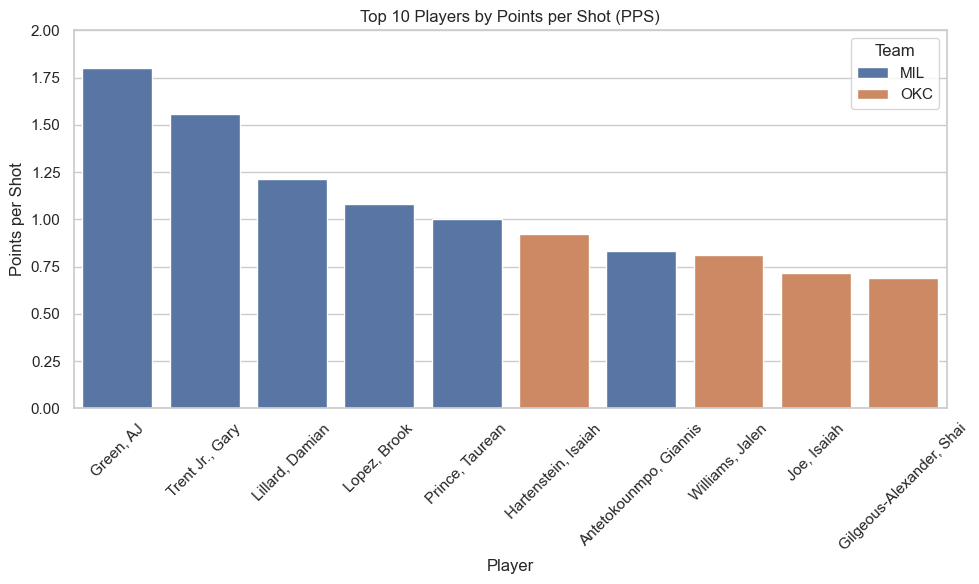

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Assume df is already loaded ---
# If not, load it manually:
# df = pd.read_csv('data_mil_okc_121724_shots.csv')

# --- 2. Add shotValue if needed ---
if 'shotValue' not in df.columns:
    df['shotValue'] = df['distance'].apply(lambda d: 3 if d >= 22 else 2)

# --- 3. TEAM LEVEL ADVANCED METRICS ---
team_advanced = df.groupby('team_nba_off').agg(
    Total_Shots=('fg', 'count'),
    Made_Shots=('fg', 'sum'),
    Total_Points=('shotValue', lambda x: (df.loc[x.index, 'fg'] * x).sum()),
    ThreePt_Made=('shotValue', lambda x: ((x == 3) & (df.loc[x.index, 'fg'] == 1)).sum()),
    ThreePt_Att=('shotValue', lambda x: (x == 3).sum()),
).reset_index()

# Calculate advanced metrics
team_advanced['FG%'] = (team_advanced['Made_Shots'] / team_advanced['Total_Shots']).round(3)
team_advanced['3P%'] = (team_advanced['ThreePt_Made'] / team_advanced['ThreePt_Att']).round(3)
team_advanced['eFG%'] = ((team_advanced['Made_Shots'] + 0.5 * team_advanced['ThreePt_Made']) / team_advanced['Total_Shots']).round(3)
team_advanced['PPS'] = (team_advanced['Total_Points'] / team_advanced['Total_Shots']).round(3)

# --- 4. PLAYER LEVEL ADVANCED METRICS ---
player_advanced = df.groupby(['team_nba_off', 'player_nba_shooter']).agg(
    Total_Shots=('fg', 'count'),
    Made_Shots=('fg', 'sum'),
    Total_Points=('shotValue', lambda x: (df.loc[x.index, 'fg'] * x).sum()),
    ThreePt_Made=('shotValue', lambda x: ((x == 3) & (df.loc[x.index, 'fg'] == 1)).sum()),
    ThreePt_Att=('shotValue', lambda x: (x == 3).sum()),
).reset_index()

# Calculate advanced metrics
player_advanced['FG%'] = (player_advanced['Made_Shots'] / player_advanced['Total_Shots']).round(3)
player_advanced['3P%'] = (player_advanced['ThreePt_Made'] / player_advanced['ThreePt_Att']).round(3)
player_advanced['eFG%'] = ((player_advanced['Made_Shots'] + 0.5 * player_advanced['ThreePt_Made']) / player_advanced['Total_Shots']).round(3)
player_advanced['PPS'] = (player_advanced['Total_Points'] / player_advanced['Total_Shots']).round(3)

# --- 5. Filter players with at least 5 shots ---
player_advanced = player_advanced[player_advanced['Total_Shots'] >= 5]
player_advanced = player_advanced.sort_values(by='PPS', ascending=False).reset_index(drop=True)

# --- 6. Display results ---
print("=== TEAM-LEVEL ADVANCED METRICS ===")
display(team_advanced[['team_nba_off', 'Total_Shots', 'FG%', '3P%', 'eFG%', 'PPS']])

print("\n=== PLAYER-LEVEL ADVANCED METRICS (min 5 shots) ===")
display(player_advanced[['team_nba_off', 'player_nba_shooter', 'Total_Shots', 'FG%', '3P%', 'eFG%', 'PPS']])

# --- 7. OPTIONAL: Quick Visualization ---
# Top 5 players by PPS
top5_players = player_advanced.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top5_players, x='player_nba_shooter', y='PPS', hue='team_nba_off')
plt.title('Top 10 Players by Points per Shot (PPS)')
plt.ylabel('Points per Shot')
plt.xlabel('Player')
plt.ylim(0, 2)
plt.legend(title='Team')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [25]:
# First, let's make sure we have our data prepared correctly
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and prepare the data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Convert 'contestLevel' to numeric using category codes
if df['contestLevel'].dtype == object:
    df['contestLevel'] = df['contestLevel'].astype('category').cat.codes

# Select features for the model
features = ['loc_x', 'loc_y', 'distance', 'closestDefDist', 'shotClock',
           'contestLevel', 'shotAngle', 'shooterSpeed', 'shooterVelAngle']

# Prepare X and y
X = df[features].fillna(0)
y = df['fg']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preparation completed.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Data preparation completed.
Training set shape: (145, 9)
Test set shape: (37, 9)


In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Load data and filter for Milwaukee (MIL) shots
df = pd.read_csv('data_mil_okc_121724_shots.csv')
df_bucks = df[df['team_nba_off'] == 'MIL'].copy()

# Enhanced Feature Engineering
df_bucks['distance_squared'] = df_bucks['distance'] ** 2
df_bucks['defender_pressure'] = 1 / (df_bucks['closestDefDist'] + 1)
df_bucks['shot_difficulty'] = df_bucks['distance'] * df_bucks['defender_pressure']
df_bucks['time_pressure'] = 1 / (df_bucks['shotClock'] + 1)
df_bucks['corner_three'] = ((df_bucks['distance'] >= 22) & (abs(df_bucks['loc_y']) <= 7.8)).astype(int)

# New features
df_bucks['shot_area'] = np.where(df_bucks['distance'] < 5, 'paint',
                                np.where(df_bucks['distance'] < 22, 'midrange', 'three'))
df_bucks['shot_area'] = pd.Categorical(df_bucks['shot_area']).codes

# Speed and angle interactions
df_bucks['speed_angle_interaction'] = df_bucks['shooterSpeed'] * np.cos(np.radians(df_bucks['shooterVelAngle']))
df_bucks['shot_clock_pressure'] = np.exp(-df_bucks['shotClock'] / 24)  # Exponential time pressure

# Convert contestLevel to numeric
contest_map = {'uncontested': 0, 'lightly_contested': 1, 'heavily_contested': 2}
df_bucks['contestLevel_numeric'] = df_bucks['contestLevel'].map(contest_map)

# Select features
features = [
    'distance',
    'closestDefDist',
    'shotClock',
    'contestLevel_numeric',
    'shotAngle',
    'shooterSpeed',
    'shooterVelAngle',
    'distance_squared',
    'defender_pressure',
    'shot_difficulty',
    'time_pressure',
    'corner_three',
    'shot_area',
    'speed_angle_interaction',
    'shot_clock_pressure'
]

X = df_bucks[features].copy()
y = df_bucks['fg']

# Handle missing values
X = X.fillna(X.mean())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Setup XGBoost with initial parameters
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Perform Grid Search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting grid search...")
# Fit the model
grid_search.fit(X_train_balanced, y_train_balanced)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test_scaled)

# Print results
print("\
Best parameters found:", grid_search.best_params_)
print("Best CV score:", round(grid_search.best_score_, 3))

print("\
Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\
Top 5 Most Important Features:")
print(feature_importance.head())

Starting grid search...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
Best CV score: 0.837
Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.54      0.64      0.58        11
           1       0.20      0.14      0.17         7

    accuracy                           0.44        18
   macro avg       0.37      0.39      0.38        18
weighted avg       0.41      0.44      0.42        18

Top 5 Most Important Features:
                feature  importance
12            shot_area    0.179614
5          shooterSpeed    0.084090
2             shotClock    0.074418
14  shot_clock_pressure    0.072110
6       shooterVelAngle    0.071053


c:\Users\sonia\Documents\vscode\.conda\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:16:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


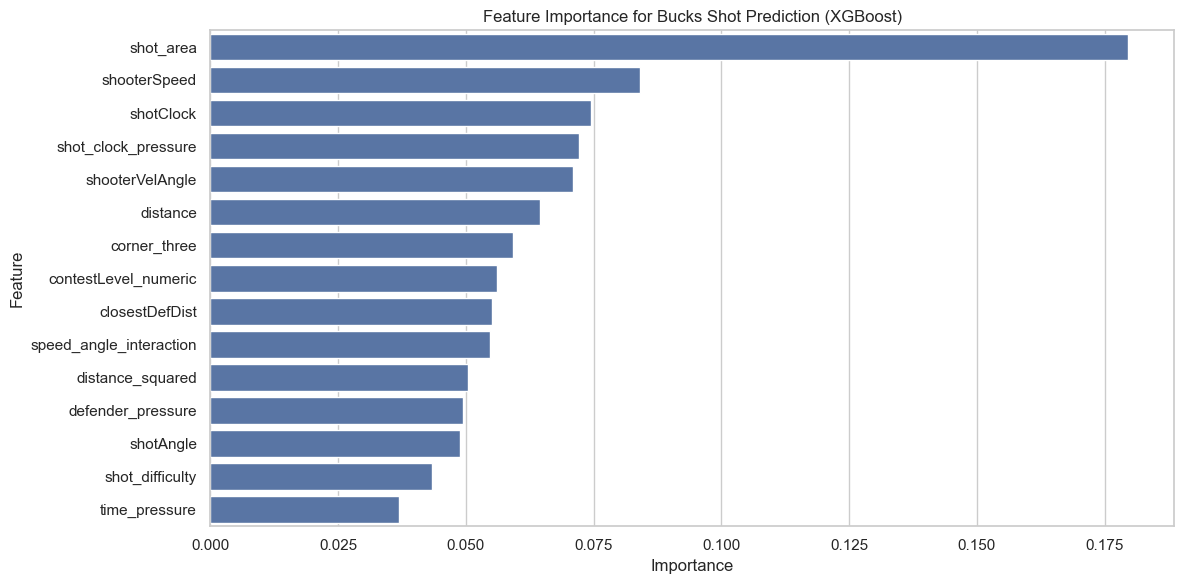

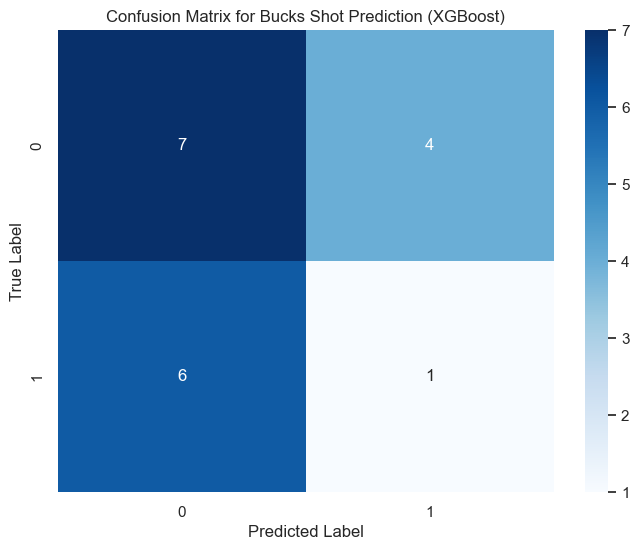

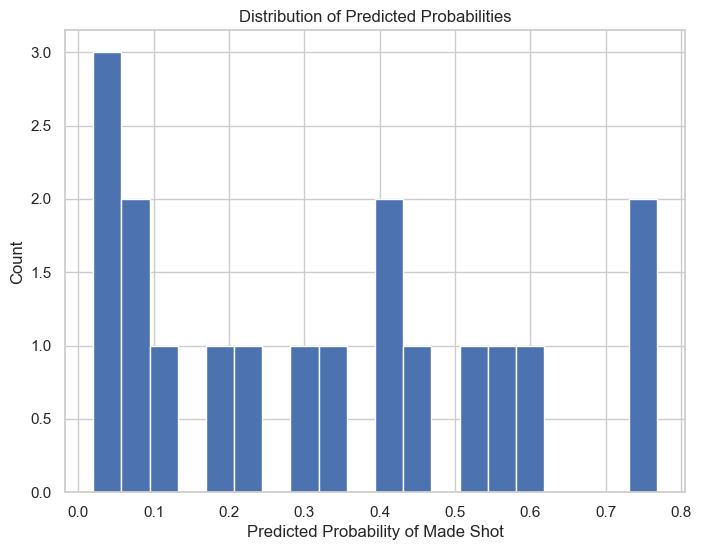

In [27]:
# Visualize the results

# Plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Bucks Shot Prediction (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Plot confusion matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Bucks Shot Prediction (XGBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate and plot probability predictions
y_prob = best_model.predict_proba(X_test_scaled)
plt.figure(figsize=(8,6))
plt.hist(y_prob[:, 1], bins=20)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Predicted Probability of Made Shot')
plt.ylabel('Count')
plt.show()

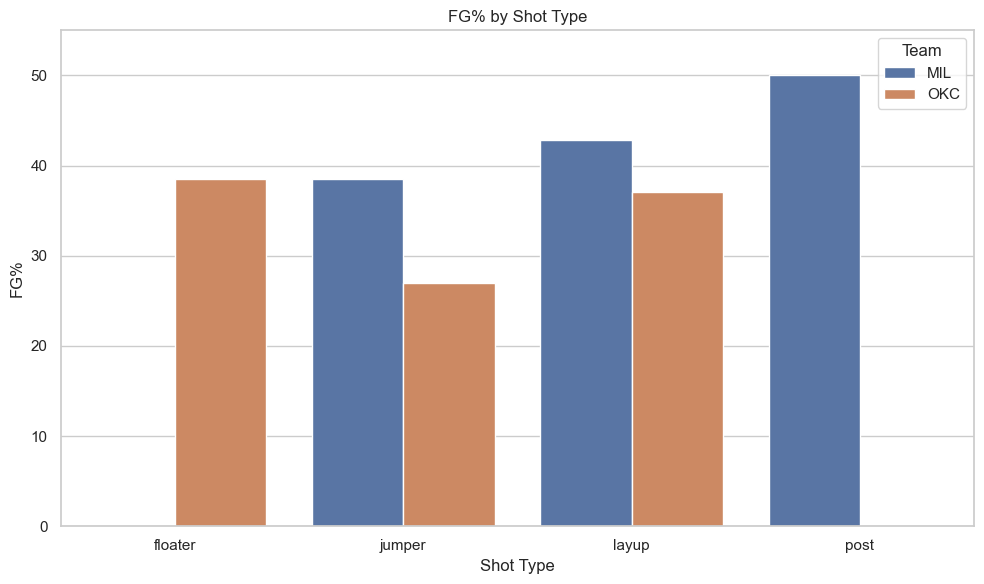

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('data_mil_okc_121724_shots.csv')

# Filter out 'heave' shots
df_filtered = df[df['shotType'] != 'heave']

# Group by team and shot type, then calculate makes and attempts
shot_type_stats = df_filtered.groupby(['team_nba_off', 'shotType']).agg(
    Attempts=('fg', 'count'),
    Makes=('fg', 'sum')
).reset_index()

# Calculate FG%
shot_type_stats['FG%'] = (shot_type_stats['Makes'] / shot_type_stats['Attempts']) * 100

# Set plot style and custom color palette
sns.set(style='whitegrid')
team_colors = {'MIL': '#4C72B0', 'OKC': '#DD8452'}  # Custom blue and orange

# Create the barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=shot_type_stats, x='shotType', y='FG%', hue='team_nba_off', palette=team_colors)

# Customize the plot
plt.title('FG% by Shot Type')
plt.xlabel('Shot Type')
plt.ylabel('FG%')
plt.ylim(0, 55)
plt.legend(title='Team')
plt.tight_layout()

# Show the plot
plt.show()


